# Asian vs African Elephant — Binary Classification
## Low-Level Preprocessing Impact: CLAHE + Sobel | ResNet-50 & DenseNet-121



---

This notebook tracks **five evaluation metrics** at every epoch for both train and validation phases.
Metrics are reported in this fixed order:

| # | Metric | Formula | What It Measures |
|---|--------|---------|------------------|
| 1 | **Accuracy** | (TP + TN) / (TP + TN + FP + FN) | Overall correctness across all predictions |
| 2 | **Precision** | TP / (TP + FP) | Of all predicted positives, how many were truly positive |
| 3 | **Recall** | TP / (TP + FN) | Of all actual positives, how many did the model correctly find |
| 4 | **Specificity** | TN / (TN + FP) | Of all actual negatives, how many did the model correctly reject |
| 5 | **F1 Score** | 2 × (Precision × Recall) / (Precision + Recall) | Harmonic mean of Precision and Recall |


---
### Notebook Structure
```
Cell 0  → Mount Google Drive
Cell 1  → Install packages
Cell 2  → Import libraries
Cell 3  → Device setup
Cell 4  → Dataset paths & hyperparameters
Cell 5  → Data transforms
Cell 6  → create_dataloaders()
Cell 7  → create_model() + unfreeze_all()
Cell 8  → compute_metrics()           
Cell 9  → train_step()                
Cell 10 → test_step()                 
Cell 11 → train() loop                 
Cell 12 → plot_loss_curves()          
Cell 13 → evaluate_model()            
Cell 14 → plot_metrics_comparison()   
Cell 15 → run_experiment()
Cell 16 → Run all experiments
Cell 17 → Final comparison charts
Cell 18 → Full summary table         
```

---
## Cell 0 — Mount Google Drive

We mount Google Drive so the notebook can access the elephant dataset stored there.
After running this cell, click the authentication link and allow access.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Install Required Packages

We install all necessary libraries:
- **torch / torchvision** — deep learning framework and pretrained models (ResNet-50, DenseNet-121)
- **scikit-learn** — provides `precision_score`, `recall_score`, `f1_score`, and `confusion_matrix` functions
- **seaborn** — for drawing the confusion matrix heatmap
- **tqdm** — progress bars during training loops
- **pandas** — for building and displaying the final structured results table

In [2]:
!pip install -q torch torchvision scikit-learn seaborn tqdm pandas

---
## Import Libraries

We import all required libraries and print version numbers to confirm the environment is correctly configured.

**Key imports for metrics:**
- `accuracy_score` — computes overall accuracy
- `precision_score` — computes precision (macro-averaged)
- `recall_score` — computes recall / sensitivity (macro-averaged)
- `f1_score` — computes F1 score (macro-averaged)
- `confusion_matrix` — used to manually derive Specificity (TN / (TN + FP))
- `pandas` — structures results into a display table

In [3]:
# PyTorch core
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm.auto import tqdm
from timeit import default_timer as timer

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(f"PyTorch version    : {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version    : 2.10.0+cu128
Torchvision version: 0.25.0+cu128


---
## Cell 3 — Setup Device-Agnostic Code

We check whether a CUDA-capable GPU is available and assign it as the compute device.
All tensors and models will be moved to this device during training.

In [4]:
# Device-agnostic code — automatically uses GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

if device == "cuda":
    print(f"GPU Name  : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU Name  : Tesla T4
GPU Memory: 15.6 GB


---
## Cell 4 — Dataset Paths & Hyperparameters

We define all dataset paths and hyperparameters in one central location.
This makes it easy to modify settings without searching through the entire notebook.

**Hyperparameter choices explained:**
- `NUM_EPOCHS = 25` — 10 epochs for Stage 1 (frozen backbone) + 15 epochs for Stage 2 (full fine-tuning)
- `LEARNING_RATE = 1e-3` — starting learning rate for Adam optimizer in Stage 1
- `UNFREEZE_EPOCH = 10` — epoch at which all layers unfreeze and lr drops to 1e-4
- `IMAGENET_MEAN / STD` — required normalization statistics for all ImageNet-pretrained models

In [5]:
# Dataset Paths — UPDATE THESE IF NEEDED

# Original (no preprocessing)
train_dir   = "/content/drive/MyDrive/Main Folder/Dataset/archive/dataset/train"
val_dir     = "/content/drive/MyDrive/Main Folder/Dataset/archive/dataset/validation"
test_dir    = "/content/drive/MyDrive/Main Folder/Dataset/archive/dataset/test"

# CLAHE preprocessed
train_clahe = "/content/drive/MyDrive/Main Folder/Dataset_CLAHE/train"
val_clahe   = "/content/drive/MyDrive/Main Folder/Dataset_CLAHE/validation"
test_clahe  = "/content/drive/MyDrive/Main Folder/Dataset_CLAHE/test"

# Sobel preprocessed
train_sobel = "/content/drive/MyDrive/Main Folder/Dataset_Sobel/train"
val_sobel   = "/content/drive/MyDrive/Main Folder/Dataset_Sobel/validation"
test_sobel  = "/content/drive/MyDrive/Main Folder/Dataset_Sobel/test"

# Hyperparameters
BATCH_SIZE     = 32
NUM_EPOCHS     = 25      # Stage 1 (epochs 0-9) + Stage 2 (epochs 10-24)
LEARNING_RATE  = 1e-3    # Stage 1 lr; automatically drops to 1e-4 at Stage 2
UNFREEZE_EPOCH = 10      # Epoch index at which full fine-tuning begins
NUM_CLASSES    = 2       # Class 0: Asian Elephant | Class 1: African Elephant
IMG_SIZE       = 224     # Standard ImageNet input resolution

# ImageNet normalization statistics — MUST match the pretrained model's training distribution
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("Configuration set successfully!")
print(f"  Epochs         : {NUM_EPOCHS} (Stage 1: 0-{UNFREEZE_EPOCH-1}, Stage 2: {UNFREEZE_EPOCH}-{NUM_EPOCHS-1})")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Learning rate  : {LEARNING_RATE} → 1e-4 at epoch {UNFREEZE_EPOCH}")
print(f"  Image size     : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Num classes    : {NUM_CLASSES} (Asian vs African Elephant)")

Configuration set successfully!
  Epochs         : 25 (Stage 1: 0-9, Stage 2: 10-24)
  Batch size     : 32
  Learning rate  : 0.001 → 1e-4 at epoch 10
  Image size     : 224x224
  Num classes    : 2 (Asian vs African Elephant)


---
## Cell 5 — Create Data Transforms

We define two separate transform pipelines — one for training and one for evaluation.

**Training transforms** apply random augmentations every epoch to create artificial variation
in the data. This reduces overfitting on small datasets like elephant images from Kaggle.

**Test/Validation transforms** apply NO augmentation — only resize and normalize.
This ensures that evaluation is always consistent and reproducible.

**Why `Normalize()` is critical:**
ResNet-50 and DenseNet-121 were pretrained on ImageNet using these exact mean and std values.
Without normalization, the input pixel distributions mismatch the pretrained weight expectations,
which significantly degrades transfer learning performance. This was missing in the original code.

In [6]:
# Training Transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),            # Resize slightly larger than needed
    transforms.RandomCrop(IMG_SIZE),          # Random 224×224 crop adds positional variation
    transforms.RandomHorizontalFlip(p=0.5),   # 50% chance of horizontal mirror
    transforms.RandomVerticalFlip(p=0.1),     # 10% chance of vertical mirror
    transforms.RandomRotation(degrees=15),    # Random rotation up to ±15 degrees
    transforms.ColorJitter(
        brightness=0.3,                       # Random brightness adjustment
        contrast=0.3,                         # Random contrast adjustment
        saturation=0.2,                       # Random saturation adjustment
        hue=0.1                               # Subtle random hue shift
    ),
    transforms.RandomGrayscale(p=0.05),       # 5% chance converts to grayscale
    transforms.ToTensor(),                    # Convert PIL Image → Tensor, scales to [0, 1]
    transforms.Normalize(mean=IMAGENET_MEAN,  # Normalize with ImageNet statistics
                         std=IMAGENET_STD)    # CRITICAL for pretrained model compatibility
])

# ── Test / Validation Transforms (no augmentation) ────────────
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Direct resize to 224×224
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,
                         std=IMAGENET_STD)
])

print("Transforms created successfully!")
print(f"  Training pipeline : {len(train_transform.transforms)} steps (with augmentation)")
print(f"  Eval pipeline     : {len(test_transform.transforms)} steps (normalize only)")

Transforms created successfully!
  Training pipeline : 9 steps (with augmentation)
  Eval pipeline     : 3 steps (normalize only)


---
## Cell 6 — create_dataloaders()

This function loads images from the folder structure on Google Drive using `ImageFolder`,
then wraps them in `DataLoader` objects for efficient batched training.

`ImageFolder` expects subfolders named after the classes:
```
train/
    asian_elephant/     ← Class 0
    african_elephant/   ← Class 1
```

**DataLoader parameters explained:**
- `shuffle=True` on train — randomizes batch order each epoch so the model cannot memorize sample ordering
- `num_workers=2` — 2 background CPU threads pre-load batches while the GPU trains, reducing idle time
- `pin_memory=True` — loads data into page-locked memory for faster CPU → GPU data transfers

In [7]:
def create_dataloaders(
    train_dir: str,
    val_dir: str,
    test_dir: str,
    train_transform: transforms.Compose,
    test_transform: transforms.Compose,
    batch_size: int = BATCH_SIZE
):
    # Load datasets from disk using folder structure as class labels
    train_data = datasets.ImageFolder(train_dir, transform=train_transform)
    val_data   = datasets.ImageFolder(val_dir,   transform=test_transform)
    test_data  = datasets.ImageFolder(test_dir,  transform=test_transform)

    class_names = train_data.classes
    print(f"  Class names : {class_names}")
    print(f"  Train size  : {len(train_data)} images")
    print(f"  Val size    : {len(val_data)} images")
    print(f"  Test size   : {len(test_data)} images")

    # Wrap in DataLoaders for batched iteration
    train_loader = DataLoader(
        train_data, batch_size=batch_size,
        shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_data, batch_size=batch_size,
        shuffle=False, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_data, batch_size=batch_size,
        shuffle=False, num_workers=2, pin_memory=True
    )

    return train_loader, val_loader, test_loader, class_names

---
## Cell 7 — create_model() and unfreeze_all()

We apply **Transfer Learning** — initializing with weights pretrained on ImageNet
(1.2 million images, 1000 classes) and adapting them for our 2-class elephant problem.

**Two-stage fine-tuning strategy:**

- **Stage 1 (Epochs 0–9):** The backbone is frozen. Only the last convolutional block
  and the new classifier head are trainable. This quickly learns elephant-specific features
  without corrupting the general ImageNet features.
- **Stage 2 (Epochs 10–24):** All layers are unfrozen at a reduced learning rate (1e-4).
  The entire network now fine-tunes together for deeper adaptation.

**`Dropout(0.3)`** is added before the final linear layer to randomly zero 30% of activations
during training, which prevents the classifier head from overfitting on small datasets.

In [8]:
def create_model(model_name: str, num_classes: int = NUM_CLASSES):
    if model_name == "resnet50":
        # Load ResNet-50 with ImageNet pretrained weights
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Freeze all backbone layers
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze last residual block (layer4) for Stage 1
        for param in model.layer4.parameters():
            param.requires_grad = True

        # Replace final fully-connected layer: 2048 → 2 classes
        model.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.fc.in_features, num_classes)
        )

    elif model_name == "densenet121":
        # Load DenseNet-121 with ImageNet pretrained weights
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        # Freeze all backbone layers
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze last dense block + final batch norm for Stage 1
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True
        for param in model.features.norm5.parameters():
            param.requires_grad = True

        # Replace classifier: 1024 → 2 classes
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(model.classifier.in_features, num_classes)
        )

    else:
        raise ValueError(f"Unknown model: '{model_name}'. Choose 'resnet50' or 'densenet121'.")

    return model.to(device)


def unfreeze_all(model: nn.Module):
    """Stage 2: Unfreezes all model parameters for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Stage 2: All layers unfrozen — {trainable:,} trainable parameters.")

---
## Cell 8 — compute_metrics()  (Updated — Specificity Added, F1 Last)

This function computes all five evaluation metrics from ground-truth labels and predicted labels.

**Confusion matrix for binary classification:**
```
                  Predicted Positive   Predicted Negative
  Actual Positive       TP                   FN
  Actual Negative       FP                   TN
```

**All five metric formulas:**
```
Accuracy    = (TP + TN) / (TP + TN + FP + FN)       — overall correctness
Precision   = TP / (TP + FP)                        — quality of positive predictions
Recall      = TP / (TP + FN)                        — coverage of actual positives
Specificity = TN / (TN + FP)                        — coverage of actual negatives
F1 Score    = 2 × Precision × Recall
              ─────────────────────                 — balance of precision & recall
              Precision + Recall
```

**Note on Specificity:** scikit-learn does not have a direct `specificity_score` function.
We compute it manually from the confusion matrix: for each class, its specificity is
`TN / (TN + FP)` where TN and FP are computed from that class's row/column in the matrix.
We then take the macro average (mean across all classes).

**`average='macro'`** computes each metric independently per class, then takes the unweighted mean.
This treats both classes equally regardless of sample count — important for fair evaluation.

In [9]:
def compute_metrics(y_true: list, y_pred: list) -> dict:
    # ── Standard metrics via scikit-learn ────────────────────
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall    = recall_score(y_true, y_pred,    average="macro", zero_division=0)
    f1        = f1_score(y_true, y_pred,        average="macro", zero_division=0)

    # ── Specificity: manually derived from confusion matrix ───
    # cm[i, j] = number of samples of true class i predicted as class j
    cm = confusion_matrix(y_true, y_pred)
    specificities = []
    for c in range(cm.shape[0]):
        # For class c: TN = all correct rejections, FP = false alarms
        TP = cm[c, c]
        FN = cm[c, :].sum() - TP          # actual positives predicted wrong
        FP = cm[:, c].sum() - TP          # other classes predicted as c
        TN = cm.sum() - TP - FN - FP      # everything else
        spec_c = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        specificities.append(spec_c)
    specificity = float(np.mean(specificities))  # macro average

    return {
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
    }


# Sanity check
sample_true = [0, 0, 1, 1, 0, 1, 0, 1]
sample_pred = [0, 1, 1, 1, 0, 0, 0, 1]
test_m = compute_metrics(sample_true, sample_pred)

print("compute_metrics() sanity check (order: Accuracy → Precision → Recall → Specificity → F1):")
for name, val in test_m.items():
    print(f"  {name:<13}: {val:.4f}")

compute_metrics() sanity check (order: Accuracy → Precision → Recall → Specificity → F1):
  accuracy     : 0.7500
  precision    : 0.7500
  recall       : 0.7500
  specificity  : 0.7500
  f1           : 0.7500


---
## Cell 9 — train_step()  (Updated — Returns 5 Metrics)

This function performs one complete forward and backward pass through all training batches (one epoch).
It follows the standard five-step PyTorch training pattern from learnpytorch.io.

**What changed:** After all batches are processed, `compute_metrics()` is called once on the
full epoch's predictions to return all five metrics: Accuracy, Precision, Recall, Specificity, F1.

**Training loop steps per batch:**
1. Forward pass — run input through the model to get logits
2. Compute loss — compare logits to true labels using CrossEntropyLoss
3. Zero gradients — clear accumulated gradients from the previous batch
4. Backward pass — compute gradients via backpropagation
5. Optimizer step — update all trainable weights using the computed gradients

In [10]:
def train_step(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: str = device
) -> tuple:
    model.train()   # Enable dropout and batch norm training behavior

    running_loss = 0.0
    all_preds, all_labels = [], []

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_logits = model(X)

        # 2. Compute loss
        loss = loss_fn(y_logits, y)
        running_loss += loss.item()

        # 3. Zero gradients
        optimizer.zero_grad()

        # 4. Backward pass
        loss.backward()

        # 5. Optimizer step — update weights
        optimizer.step()

        # Collect batch predictions for epoch-level metric computation
        preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    # Average loss across all batches in this epoch
    avg_loss = running_loss / len(dataloader)

    # Compute all five metrics on the full epoch's predictions
    m = compute_metrics(all_labels, all_preds)

    return avg_loss, m["accuracy"], m["precision"], m["recall"], m["specificity"], m["f1"]

---
## Cell 10 — test_step()  

This function evaluates the model on the validation (or test) set without updating any weights.
It mirrors `train_step()` but with two critical differences:

- **`model.eval()`** — disables Dropout layers and switches BatchNorm to use running statistics
  instead of batch statistics. This produces deterministic, stable predictions.
- **`torch.inference_mode()`** — completely disables gradient tracking and autograd,
  which is faster than `torch.no_grad()` and uses less memory.

There is no `loss.backward()` or `optimizer.step()` — we only measure performance here, not learn.
Returns the same five metrics as `train_step()` so curves can be plotted side by side.

In [11]:
def test_step(
    model: nn.Module,
    dataloader: DataLoader,
    loss_fn: nn.Module,
    device: str = device
) -> tuple:
    model.eval()   # Disable dropout; use running BatchNorm statistics

    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.inference_mode():   # No gradient computation needed
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            # Forward pass only — no backward
            y_logits = model(X)

            # Compute loss for monitoring (not for optimization)
            loss = loss_fn(y_logits, y)
            running_loss += loss.item()

            # Predicted class = index of highest logit
            preds = y_logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    m = compute_metrics(all_labels, all_preds)

    return avg_loss, m["accuracy"], m["precision"], m["recall"], m["specificity"], m["f1"]

---
## Cell 11 — train() Loop

The main training loop calls `train_step()` and `test_step()` every epoch and records all five metrics.

**Key components:**
- **tqdm progress bar** — shows real-time epoch count during training
- **CosineAnnealingLR scheduler** — smoothly decays the learning rate from its initial value
  toward zero following a cosine curve. This prevents oscillation near the minimum and
  helps the model converge to a sharper, better-generalizing solution.
- **Two-stage unfreeze** — at `unfreeze_epoch`, all backbone layers are unfrozen and
  the optimizer's learning rate is reduced to 1e-4 for careful full fine-tuning.
- **Best model checkpoint** — the model state with the highest validation F1 score is saved.
  At the end of training the best weights are restored automatically.
- **Results dictionary** — stores 10 lists (train + val for each of the 5 metrics),
  one value per epoch, for use in plotting and final reporting.

In [12]:
def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int = NUM_EPOCHS,
    unfreeze_epoch: int = UNFREEZE_EPOCH,
    device: str = device
) -> dict:
    # Initialize storage — one list per metric per phase
    results = {
        "train_loss"        : [], "val_loss"        : [],
        "train_acc"         : [], "val_acc"         : [],
        "train_precision"   : [], "val_precision"   : [],
        "train_recall"      : [], "val_recall"      : [],
        "train_specificity" : [], "val_specificity" : [],
        "train_f1"          : [], "val_f1"          : [],
    }

    # CosineAnnealingLR: smoothly decays lr from initial value → eta_min over T_max epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    # Track best model by validation F1
    best_val_f1 = 0.0
    best_model_state = None

    for epoch in tqdm(range(epochs), desc="Training"):

        # ── Two-Stage Fine-Tuning Switch ──────────────────────
        if epoch == unfreeze_epoch:
            print(f"\n[Epoch {epoch+1}] >>> Stage 2: Unfreezing all layers, lr → 1e-4")
            unfreeze_all(model)
            for group in optimizer.param_groups:
                group["lr"] = 1e-4


        # Training step — returns 5 metrics
        tr_loss, tr_acc, tr_prec, tr_rec, tr_spec, tr_f1 = train_step(
            model, train_loader, loss_fn, optimizer, device
        )

        # Validation step — returns 5 metrics
        va_loss, va_acc, va_prec, va_rec, va_spec, va_f1 = test_step(
            model, val_loader, loss_fn, device
        )

        # Step learning rate scheduler
        scheduler.step()

        # Save best model checkpoint based on validation F1
        if va_f1 > best_val_f1:
            best_val_f1 = va_f1
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

        # Store all metrics for this epoch
        results["train_loss"].append(tr_loss)
        results["val_loss"].append(va_loss)
        results["train_acc"].append(tr_acc)
        results["val_acc"].append(va_acc)
        results["train_precision"].append(tr_prec)
        results["val_precision"].append(va_prec)
        results["train_recall"].append(tr_rec)
        results["val_recall"].append(va_rec)
        results["train_specificity"].append(tr_spec)
        results["val_specificity"].append(va_spec)
        results["train_f1"].append(tr_f1)
        results["val_f1"].append(va_f1)

        # Print epoch summary — order: Acc | Prec | Rec | Spec | F1
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Loss: {tr_loss:.4f}/{va_loss:.4f} | "
            f"Acc: {tr_acc*100:.1f}%/{va_acc*100:.1f}% | "
            f"Prec: {tr_prec:.3f}/{va_prec:.3f} | "
            f"Rec: {tr_rec:.3f}/{va_rec:.3f} | "
            f"Spec: {tr_spec:.3f}/{va_spec:.3f} | "
            f"F1: {tr_f1:.3f}/{va_f1:.3f} | "
            f"LR: {current_lr:.2e}"
        )

    # Restore best model weights
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\nBest Val F1: {best_val_f1:.4f} — best model weights restored.")

    return results

---
## Cell 12 — plot_loss_curves()  (6 Subplots for 5 Metrics + Loss)

This function visualizes training and validation curves for all five metrics plus loss
across every epoch, arranged in a 2×3 grid.

**How to read each subplot:**
- **Loss** — should steadily decrease. If val loss rises while train loss drops, the model is overfitting.
- **Accuracy** — overall correctness. Fast to converge but can be misleading with class imbalance.
- **Precision** — high precision means few false positives. Watch if it drops after unfreezing.
- **Recall** — high recall means the model finds most true positives. Should stabilize by epoch 15+.
- **Specificity** — high specificity means few false alarms on the negative class. Complements recall.
- **F1 Score** — the primary combined metric. Should be the most stable of all five curves.

The **green dotted vertical line** marks the epoch where Stage 2 fine-tuning begins.
You will typically see a brief dip in metrics right after the unfreeze as all layers start adapting.

In [13]:
def plot_loss_curves(results: dict, title: str = ""):
    epochs = range(1, len(results["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"{title} — Training & Validation Curves",
                 fontsize=15, fontweight="bold", y=1.01)

    # Configuration: (axis, train_key, val_key, y-label, subplot title)
    # Order: Loss | Accuracy | Precision | Recall | Specificity | F1
    plot_config = [
        (axes[0, 0], "train_loss",        "val_loss",        "Loss",  "Loss"),
        (axes[0, 1], "train_acc",         "val_acc",         "Score", "Accuracy"),
        (axes[0, 2], "train_precision",   "val_precision",   "Score", "Precision"),
        (axes[1, 0], "train_recall",      "val_recall",      "Score", "Recall"),
        (axes[1, 1], "train_specificity", "val_specificity", "Score", "Specificity"),
        (axes[1, 2], "train_f1",          "val_f1",          "Score", "F1 Score"),
    ]

    train_color = "#2196F3"   # Blue for training
    val_color   = "#FF5722"   # Orange for validation

    for ax, train_key, val_key, ylabel, plot_title in plot_config:
        ax.plot(epochs, results[train_key],
                color=train_color, label="Train",
                linewidth=2, marker="o", markersize=3)
        ax.plot(epochs, results[val_key],
                color=val_color, label="Val",
                linewidth=2, linestyle="--", marker="s", markersize=3)

        # Mark the Stage 2 unfreeze epoch
        if UNFREEZE_EPOCH < len(list(epochs)):
            ax.axvline(x=UNFREEZE_EPOCH + 1, color="green",
                       linestyle=":", linewidth=1.5, alpha=0.8,
                       label=f"Unfreeze (ep {UNFREEZE_EPOCH + 1})")

        ax.set_title(plot_title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

---
## Cell 13 — evaluate_model()

After training is complete, this function evaluates the best saved model on the **held-out test set**.
The test set is only used here — never during training — ensuring unbiased final evaluation.

**Outputs produced:**
1. **Confusion matrix (counts)** — shows the raw number of correct and incorrect predictions per class
2. **Confusion matrix (normalized)** — shows proportions (what fraction of each class was correct)
3. **Per-class classification report** — precision, recall, F1 for each class individually
4. **Macro-averaged summary** — all five metrics printed in fixed order: Accuracy, Precision, Recall, Specificity, F1

**Reading the confusion matrix:**
- Diagonal = correct predictions (want large values)
- Off-diagonal = misclassifications (want small or zero values)

In [14]:
def evaluate_model(
    model: nn.Module,
    test_loader: DataLoader,
    class_names: list,
    device: str = device
) -> dict:
    model.eval()
    all_preds, all_labels = [], []

    with torch.inference_mode():
        for X, y in test_loader:
            X = X.to(device)
            logits = model(X)
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())

    # Compute all five metrics
    metrics = compute_metrics(all_labels, all_preds)

    # 1. Confusion Matrices
    cm = confusion_matrix(all_labels, all_preds)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Raw count matrix
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], linewidths=0.5)
    axes[0].set_title("Confusion Matrix (Counts)", fontweight="bold")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    # Normalized matrix — proportion of each true class correctly classified
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Oranges",
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], linewidths=0.5)
    axes[1].set_title("Confusion Matrix (Normalized)", fontweight="bold")
    axes[1].set_xlabel("Predicted Label")
    axes[1].set_ylabel("True Label")

    plt.suptitle(
        f"Test Set Evaluation  |  "
        f"Acc: {metrics['accuracy']*100:.2f}%  |  "
        f"Spec: {metrics['specificity']:.4f}  |  "
        f"F1: {metrics['f1']:.4f}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    # 2. Per-Class Classification Report
    print("\n" + "─"*58)
    print(" Per-Class Classification Report")
    print("─"*58)
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names,
        digits=4
    ))

    # 3. Five-Metric Summary (fixed order)
    print("─"*58)
    print(" Macro-Averaged Test Metrics (Order: Acc → Prec → Rec → Spec → F1)")
    print("─"*58)
    print(f"  1. Accuracy    : {metrics['accuracy']*100:.2f}%")
    print(f"  2. Precision   : {metrics['precision']:.4f}")
    print(f"  3. Recall      : {metrics['recall']:.4f}")
    print(f"  4. Specificity : {metrics['specificity']:.4f}")
    print(f"  5. F1 Score    : {metrics['f1']:.4f}")
    print("─"*58)

    return metrics

---
## Cell 14 — plot_metrics_comparison()  (Updated — 5 Metric Bar Charts)

After all 6 experiments finish, this function creates a comprehensive comparison visualization.
Five grouped bar charts — one per metric — are arranged in a 2×3 grid.
Each chart shows all 6 model–dataset combinations side by side.

**Color coding:**
- Blue shades = ResNet-50 (Original, CLAHE, Sobel)
- Purple/gold shades = DenseNet-121 (Original, CLAHE, Sobel)

This directly answers: **Which model + preprocessing combination performs best
across all five metrics?**

In [22]:
import matplotlib.pyplot as plt

def plot_metrics_comparison(all_metrics: dict):
    experiments = [f"{m.upper()}\n{d}" for (m, d) in all_metrics]

    metric_keys   = ["accuracy", "precision", "recall", "specificity", "f1"]
    metric_labels = ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score"]

    bar_colors = [
        "#4C72B0", "#55A868", "#C44E52",
        "#8172B2", "#CCB974", "#64B5CD"
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(
        "Final Test Set Comparison — All 5 Metrics\n"
        "ResNet-50 vs DenseNet-121  ×  Original / CLAHE / Sobel",
        fontsize=14, fontweight="bold"
    )

    # ✅ FIX: convert to list (prevents StopIteration)
    axes = axes.flatten()

    # First 5 plots
    for i, (metric_key, metric_label) in enumerate(zip(metric_keys, metric_labels)):
        ax = axes[i]

        values = [all_metrics[k][metric_key] for k in all_metrics]

        display_values = [
            v * 100 if metric_key == "accuracy" else v
            for v in values
        ]

        ylabel = "Accuracy (%)" if metric_key == "accuracy" else "Score (0–1)"

        bars = ax.bar(
            experiments,
            display_values,
            color=bar_colors,
            edgecolor="black",
            linewidth=0.7
        )

        for bar, val in zip(bars, display_values):
            label_text = f"{val:.1f}%" if metric_key == "accuracy" else f"{val:.3f}"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                label_text,
                ha="center",
                va="bottom",
                fontsize=8.5,
                fontweight="bold"
            )

        ax.set_title(metric_label, fontsize=12, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_ylim(0, max(display_values) * 1.18)
        ax.tick_params(axis="x", labelsize=8)
        ax.grid(axis="y", alpha=0.3)

    # 6th panel (summary box)
    ax6 = axes[5]   # ✅ direct indexing (no next(), no iterator issues)
    ax6.axis("off")

    best_key = max(all_metrics, key=lambda k: all_metrics[k]["f1"])
    best_m   = all_metrics[best_key]

    summary_text = (
        f"🏆 Best Model (by F1)\n\n"
        f"{best_key[0].upper()} + {best_key[1]}\n\n"
        f"Accuracy    : {best_m['accuracy']*100:.2f}%\n"
        f"Precision   : {best_m['precision']:.4f}\n"
        f"Recall      : {best_m['recall']:.4f}\n"
        f"Specificity : {best_m['specificity']:.4f}\n"
        f"F1 Score    : {best_m['f1']:.4f}"
    )

    ax6.text(
        0.5, 0.5,
        summary_text,
        ha="center",
        va="center",
        fontsize=12,
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.8", facecolor="#E8F5E9", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

---
## Cell 15 — run_experiment()

This is the master orchestration function that ties all previous functions together.
One call to `run_experiment()` runs a complete experiment for a single model–dataset combination:

1. **Load data** — calls `create_dataloaders()` for the specified dataset variant
2. **Create model** — calls `create_model()` with frozen backbone (Stage 1)
3. **Set up loss and optimizer** — CrossEntropyLoss + Adam
4. **Train** — calls `train()` with two-stage fine-tuning and metric tracking
5. **Plot training curves** — calls `plot_loss_curves()` showing all 5 metrics over epochs
6. **Evaluate on test set** — calls `evaluate_model()` and prints the final 5-metric report

Returns a dictionary of all five test metrics for later comparison.

In [16]:
def run_experiment(
    model_name: str,
    train_dir: str,
    val_dir: str,
    test_dir: str,
    dataset_tag: str,
    epochs: int = NUM_EPOCHS
) -> dict:
    tag = f"{model_name.upper()} | {dataset_tag}"
    print(f"\n{'='*65}")
    print(f"  EXPERIMENT: {tag}")
    print(f"{'='*65}")

    # Step 1: Load Data
    print("\n[Step 1] Loading data...")
    train_loader, val_loader, test_loader, class_names = create_dataloaders(
        train_dir=train_dir,
        val_dir=val_dir,
        test_dir=test_dir,
        train_transform=train_transform,
        test_transform=test_transform
    )

    # Step 2: Create Model
    print("\n[Step 2] Creating model...")
    model = create_model(model_name=model_name, num_classes=NUM_CLASSES)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Architecture   : {model_name}")
    print(f"  Trainable params (Stage 1): {trainable:,} / {total:,}")

    # Step 3: Loss + Optimizer
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )

    # Step 4: Train
    print(f"\n[Step 3] Training for {epochs} epochs...")
    print(f"  Columns → Loss tr/va | Acc | Prec | Rec | Spec | F1 | LR")
    print("  " + "-"*75)

    start_time = timer()
    results = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        epochs=epochs,
        unfreeze_epoch=UNFREEZE_EPOCH
    )
    end_time = timer()
    print(f"\n  Training time: {(end_time - start_time) / 60:.2f} minutes")

    # Step 5: Plot Training Curves
    print("\n[Step 4] Plotting training curves...")
    plot_loss_curves(results, title=tag)

    # Step 6: Evaluate on Test Set
    print("\n[Step 5] Evaluating on test set...")
    test_metrics = evaluate_model(
        model=model,
        test_loader=test_loader,
        class_names=class_names
    )

    print(f"\nExperiment complete: {tag}")
    return test_metrics

---
## Cell 16 — Run All 6 Experiments

We run every combination of model and preprocessing variant in a single loop.
All results are stored in `all_metrics` — a dictionary keyed by `(model_name, dataset_tag)`.

**6 total experiments:**
- ResNet-50 × {Original, CLAHE, Sobel}
- DenseNet-121 × {Original, CLAHE, Sobel}

Each experiment runs for 25 epochs and takes approximately 5–10 minutes on a Colab T4 GPU.
Estimated total runtime: **30–60 minutes**.


  EXPERIMENT: RESNET50 | Original

[Step 1] Loading data...
  Class names : ['African', 'Asian']
  Train size  : 714 images
  Val size    : 126 images
  Test size   : 188 images

[Step 2] Creating model...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 90.4MB/s]


  Architecture   : resnet50
  Trainable params (Stage 1): 14,968,834 / 23,512,130

[Step 3] Training for 25 epochs...
  Columns → Loss tr/va | Acc | Prec | Rec | Spec | F1 | LR
  ---------------------------------------------------------------------------


Training:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01/25 | Loss: 0.6186/1.4746 | Acc: 63.7%/70.6% | Prec: 0.638/0.708 | Rec: 0.637/0.706 | Spec: 0.637/0.706 | F1: 0.637/0.706 | LR: 9.96e-04
Epoch 02/25 | Loss: 0.5338/1.4716 | Acc: 75.2%/69.8% | Prec: 0.757/0.726 | Rec: 0.752/0.698 | Spec: 0.752/0.698 | F1: 0.751/0.689 | LR: 9.84e-04
Epoch 03/25 | Loss: 0.4540/0.6833 | Acc: 79.4%/71.4% | Prec: 0.795/0.715 | Rec: 0.794/0.714 | Spec: 0.794/0.714 | F1: 0.794/0.714 | LR: 9.65e-04
Epoch 04/25 | Loss: 0.4508/0.7461 | Acc: 79.6%/68.3% | Prec: 0.799/0.684 | Rec: 0.796/0.683 | Spec: 0.796/0.683 | F1: 0.795/0.682 | LR: 9.38e-04
Epoch 05/25 | Loss: 0.3688/0.8579 | Acc: 83.6%/73.0% | Prec: 0.839/0.751 | Rec: 0.836/0.730 | Spec: 0.836/0.730 | F1: 0.836/0.725 | LR: 9.05e-04
Epoch 06/25 | Loss: 0.3389/0.8266 | Acc: 85.2%/67.5% | Prec: 0.852/0.675 | Rec: 0.852/0.675 | Spec: 0.852/0.675 | F1: 0.852/0.674 | LR: 8.65e-04
Epoch 07/25 | Loss: 0.3119/1.3305 | Acc: 86.8%/69.0% | Prec: 0.868/0.691 | Rec: 0.868/0.690 | Spec: 0.868/0.690 | F1: 0.868/0.690 

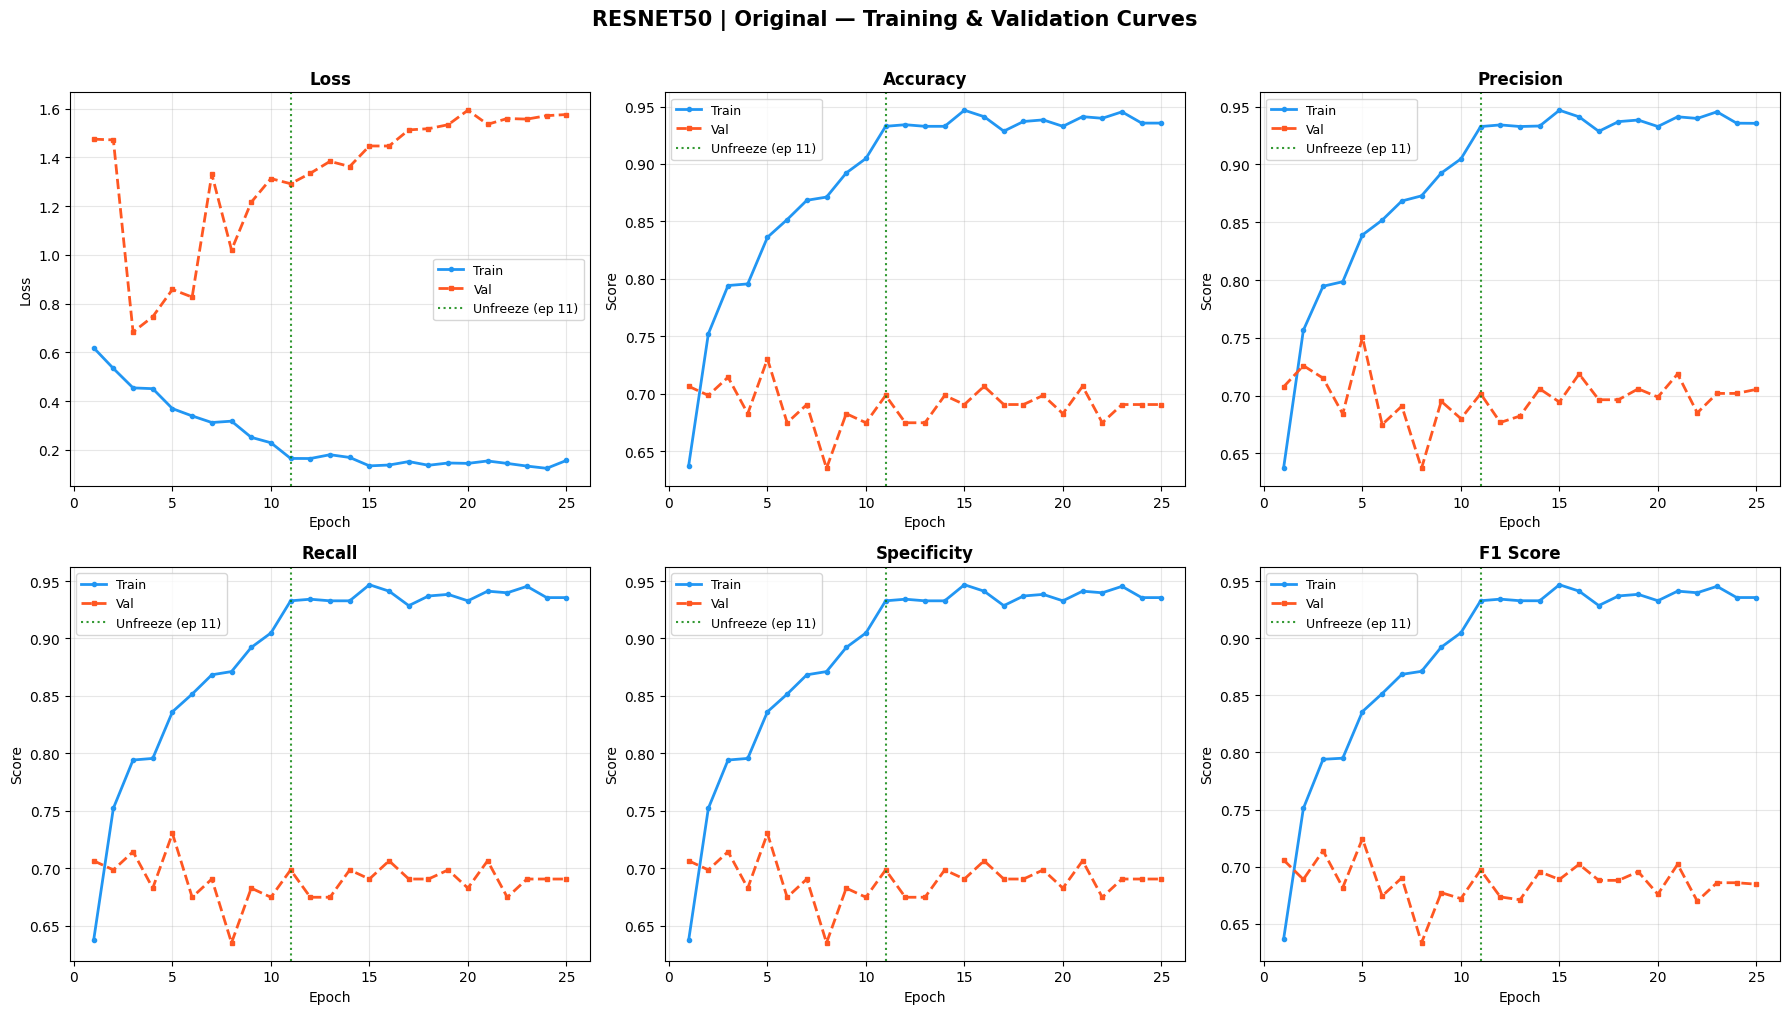


[Step 5] Evaluating on test set...


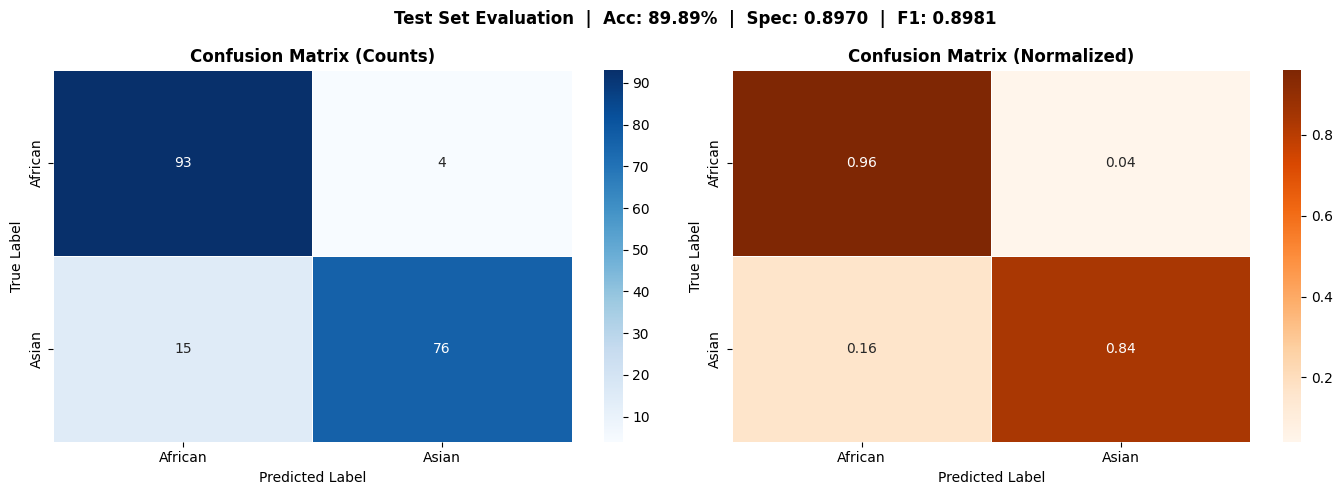


──────────────────────────────────────────────────────────
 Per-Class Classification Report
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     African     0.8611    0.9588    0.9073        97
       Asian     0.9500    0.8352    0.8889        91

    accuracy                         0.8989       188
   macro avg     0.9056    0.8970    0.8981       188
weighted avg     0.9041    0.8989    0.8984       188

──────────────────────────────────────────────────────────
 Macro-Averaged Test Metrics (Order: Acc → Prec → Rec → Spec → F1)
──────────────────────────────────────────────────────────
  1. Accuracy    : 89.89%
  2. Precision   : 0.9056
  3. Recall      : 0.8970
  4. Specificity : 0.8970
  5. F1 Score    : 0.8981
──────────────────────────────────────────────────────────

Experiment complete: RESNET50 | Original

  EXPERIMENT: RESNET50 | CLAHE

[Step 1] Loading data...
  Class names : ['African', 'Asian']
  Train si

Training:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01/25 | Loss: 0.6216/0.6449 | Acc: 65.0%/67.5% | Prec: 0.650/0.783 | Rec: 0.650/0.675 | Spec: 0.650/0.675 | F1: 0.650/0.640 | LR: 9.96e-04
Epoch 02/25 | Loss: 0.5296/1.1643 | Acc: 75.1%/69.0% | Prec: 0.751/0.699 | Rec: 0.751/0.690 | Spec: 0.751/0.690 | F1: 0.751/0.687 | LR: 9.84e-04
Epoch 03/25 | Loss: 0.4744/0.7021 | Acc: 78.9%/72.2% | Prec: 0.794/0.723 | Rec: 0.789/0.722 | Spec: 0.789/0.722 | F1: 0.788/0.722 | LR: 9.65e-04
Epoch 04/25 | Loss: 0.4239/0.5910 | Acc: 80.4%/72.2% | Prec: 0.804/0.724 | Rec: 0.804/0.722 | Spec: 0.804/0.722 | F1: 0.804/0.722 | LR: 9.38e-04
Epoch 05/25 | Loss: 0.3496/0.7329 | Acc: 84.3%/73.0% | Prec: 0.843/0.730 | Rec: 0.843/0.730 | Spec: 0.843/0.730 | F1: 0.843/0.730 | LR: 9.05e-04
Epoch 06/25 | Loss: 0.3558/1.2174 | Acc: 84.7%/70.6% | Prec: 0.847/0.711 | Rec: 0.847/0.706 | Spec: 0.847/0.706 | F1: 0.847/0.705 | LR: 8.65e-04
Epoch 07/25 | Loss: 0.3362/0.9712 | Acc: 85.9%/69.8% | Prec: 0.860/0.712 | Rec: 0.859/0.698 | Spec: 0.859/0.698 | F1: 0.858/0.693 

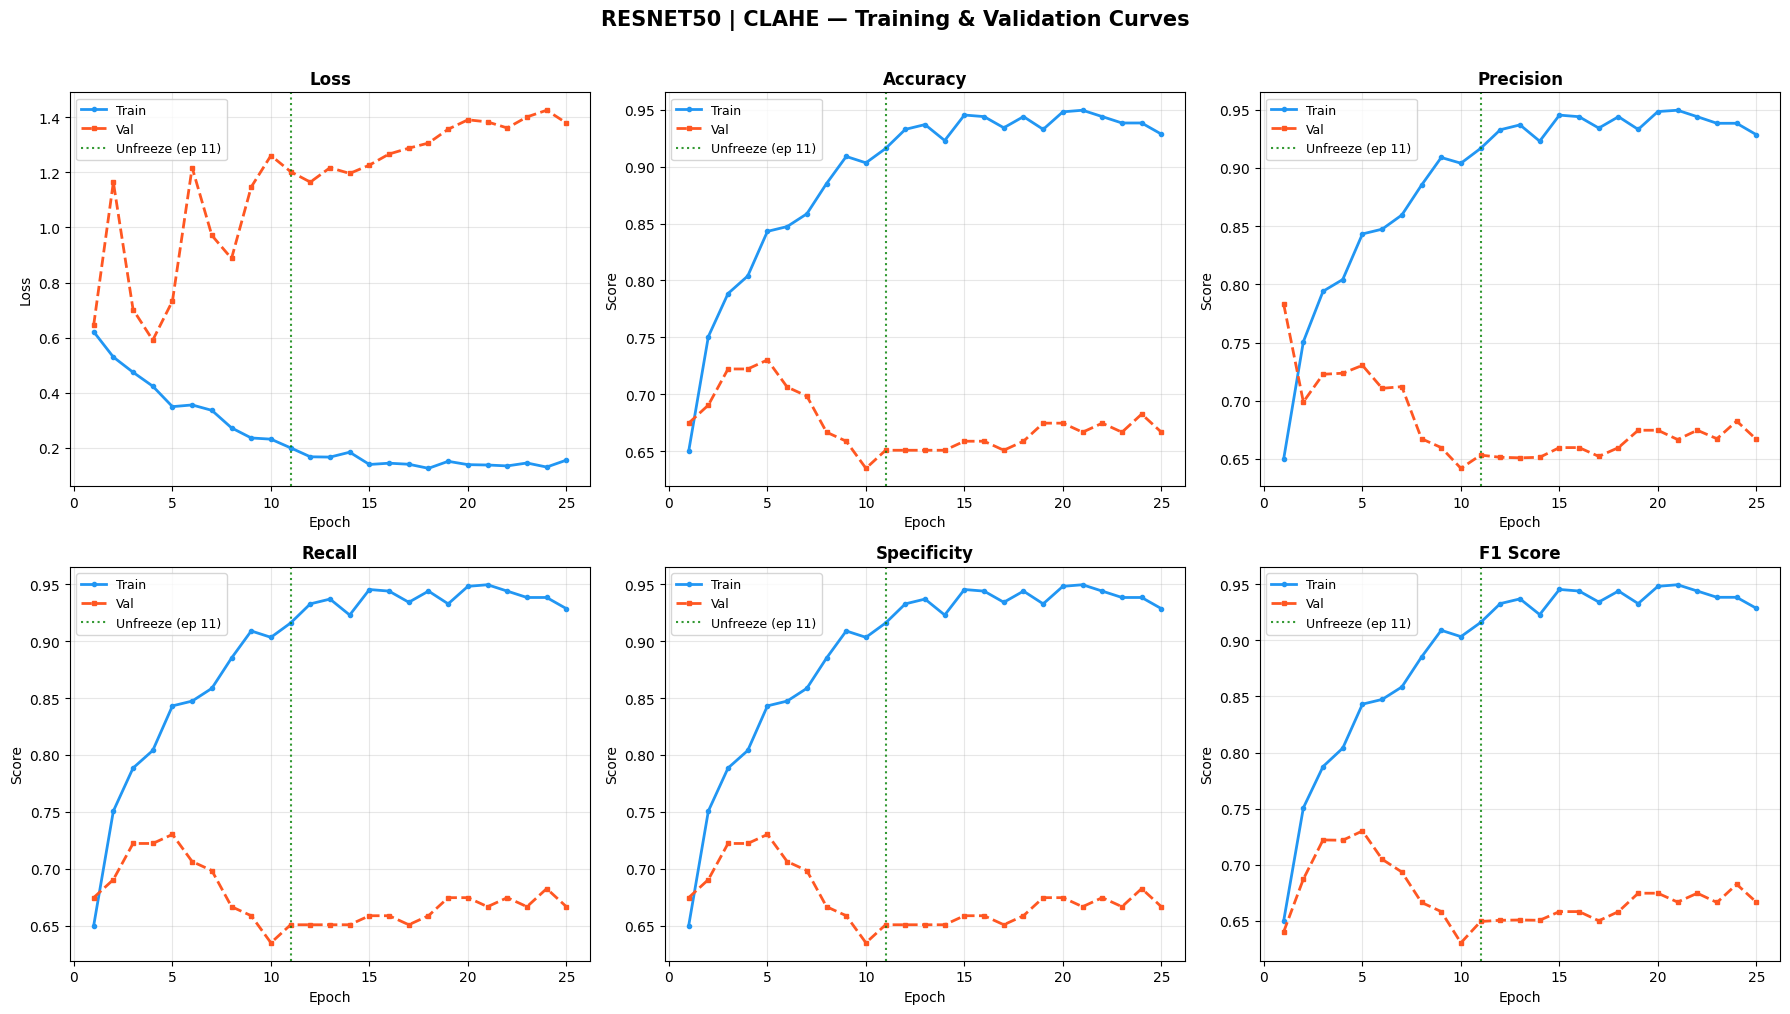


[Step 5] Evaluating on test set...


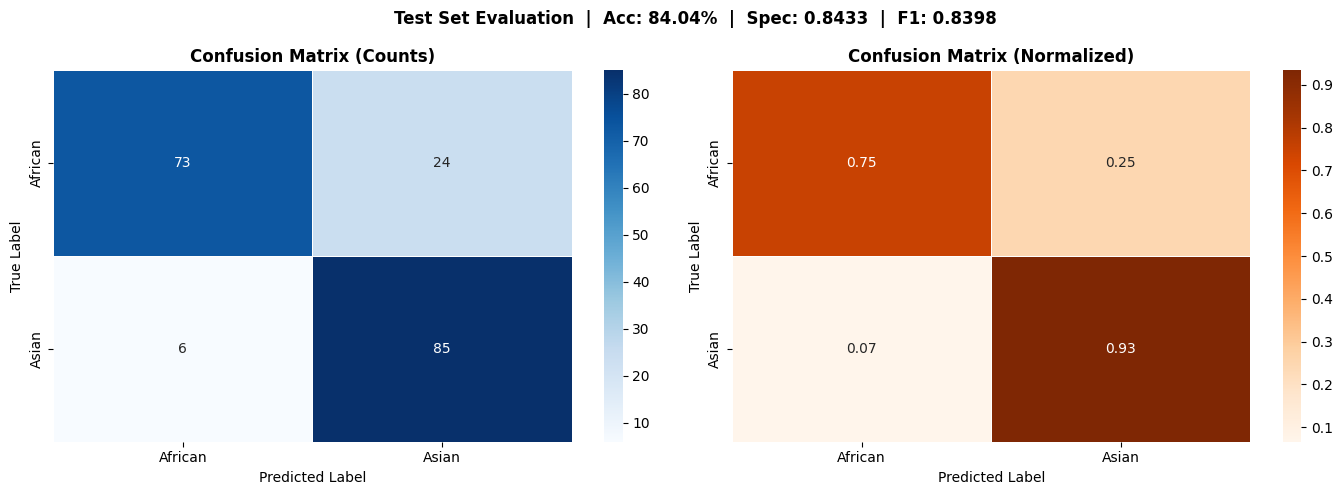


──────────────────────────────────────────────────────────
 Per-Class Classification Report
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     African     0.9241    0.7526    0.8295        97
       Asian     0.7798    0.9341    0.8500        91

    accuracy                         0.8404       188
   macro avg     0.8519    0.8433    0.8398       188
weighted avg     0.8542    0.8404    0.8394       188

──────────────────────────────────────────────────────────
 Macro-Averaged Test Metrics (Order: Acc → Prec → Rec → Spec → F1)
──────────────────────────────────────────────────────────
  1. Accuracy    : 84.04%
  2. Precision   : 0.8519
  3. Recall      : 0.8433
  4. Specificity : 0.8433
  5. F1 Score    : 0.8398
──────────────────────────────────────────────────────────

Experiment complete: RESNET50 | CLAHE

  EXPERIMENT: RESNET50 | Sobel

[Step 1] Loading data...
  Class names : ['African', 'Asian']
  Train size 

Training:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01/25 | Loss: 0.6976/0.7040 | Acc: 50.7%/50.8% | Prec: 0.507/0.585 | Rec: 0.507/0.508 | Spec: 0.507/0.508 | F1: 0.505/0.364 | LR: 9.96e-04
Epoch 02/25 | Loss: 0.6860/0.7351 | Acc: 56.2%/50.0% | Prec: 0.564/0.500 | Rec: 0.562/0.500 | Spec: 0.562/0.500 | F1: 0.558/0.447 | LR: 9.84e-04
Epoch 03/25 | Loss: 0.6638/0.8087 | Acc: 61.3%/54.8% | Prec: 0.626/0.589 | Rec: 0.613/0.548 | Spec: 0.613/0.548 | F1: 0.603/0.488 | LR: 9.65e-04
Epoch 04/25 | Loss: 0.6557/0.7672 | Acc: 61.6%/54.8% | Prec: 0.618/0.560 | Rec: 0.616/0.548 | Spec: 0.616/0.548 | F1: 0.615/0.522 | LR: 9.38e-04
Epoch 05/25 | Loss: 0.6612/0.6635 | Acc: 59.8%/56.3% | Prec: 0.604/0.581 | Rec: 0.598/0.563 | Spec: 0.598/0.563 | F1: 0.592/0.539 | LR: 9.05e-04
Epoch 06/25 | Loss: 0.6571/0.7358 | Acc: 63.4%/56.3% | Prec: 0.640/0.565 | Rec: 0.634/0.563 | Spec: 0.634/0.563 | F1: 0.631/0.560 | LR: 8.65e-04
Epoch 07/25 | Loss: 0.6429/0.7247 | Acc: 62.5%/57.1% | Prec: 0.629/0.572 | Rec: 0.625/0.571 | Spec: 0.625/0.571 | F1: 0.621/0.571 

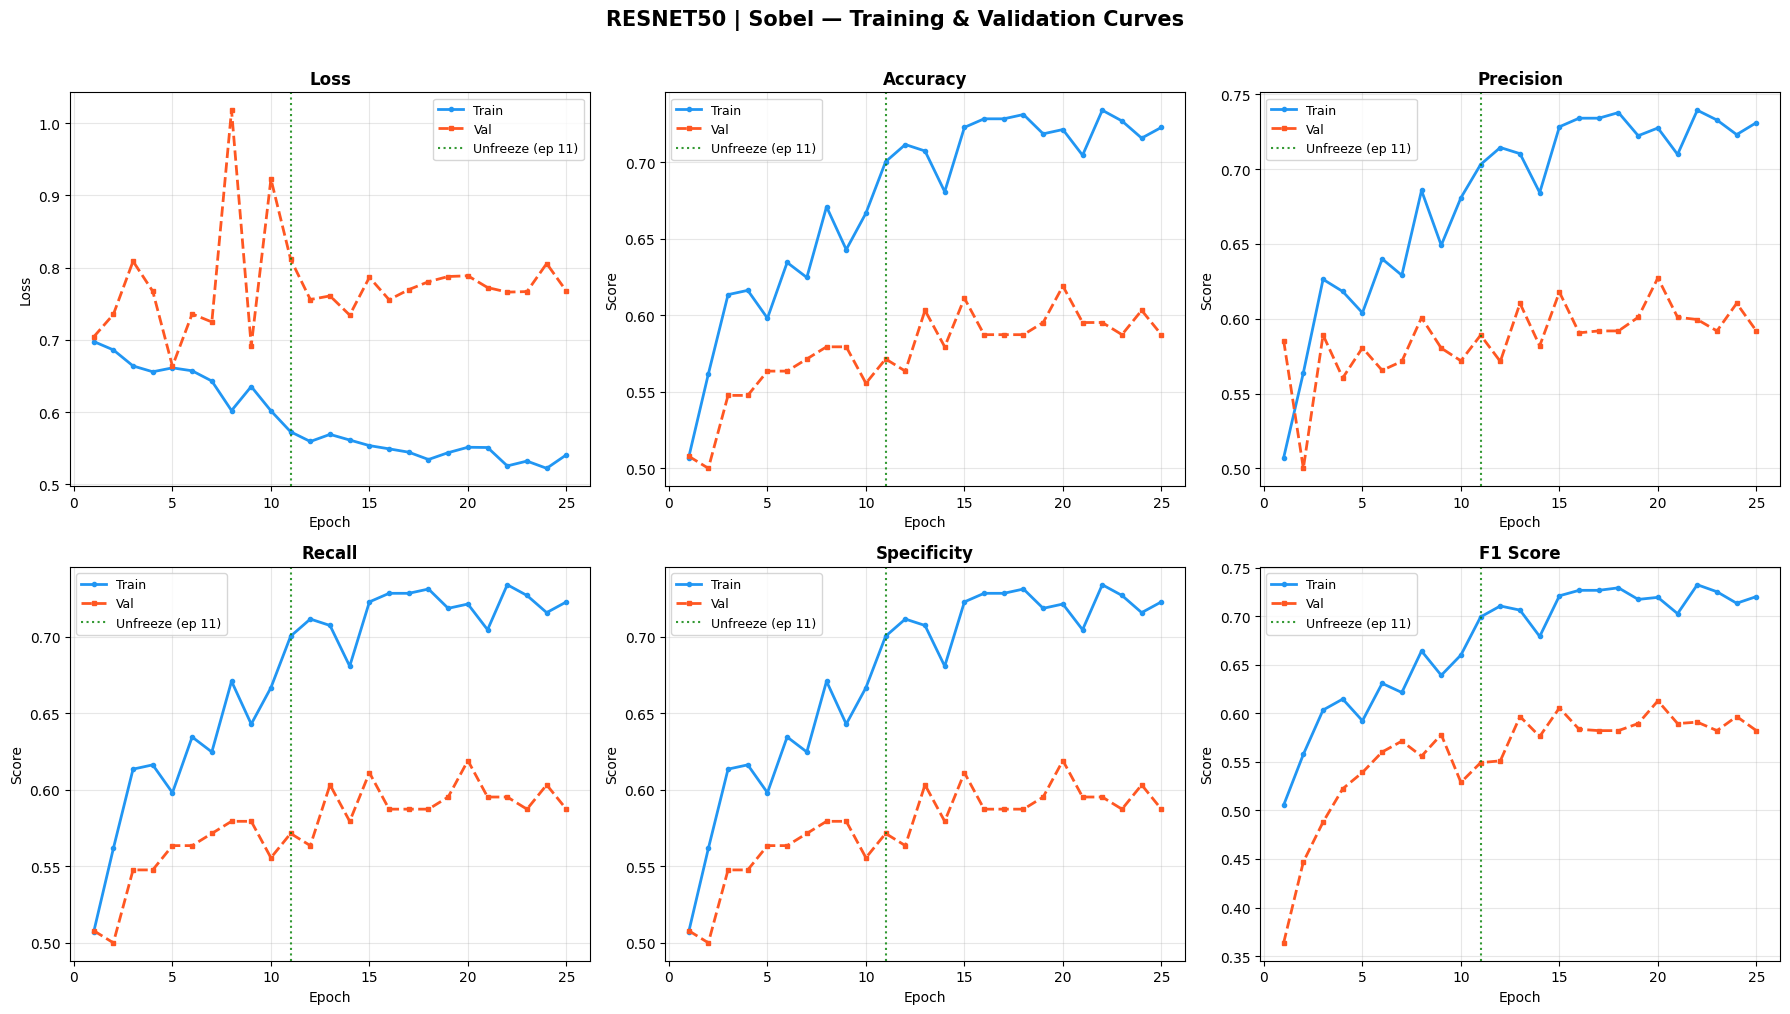


[Step 5] Evaluating on test set...


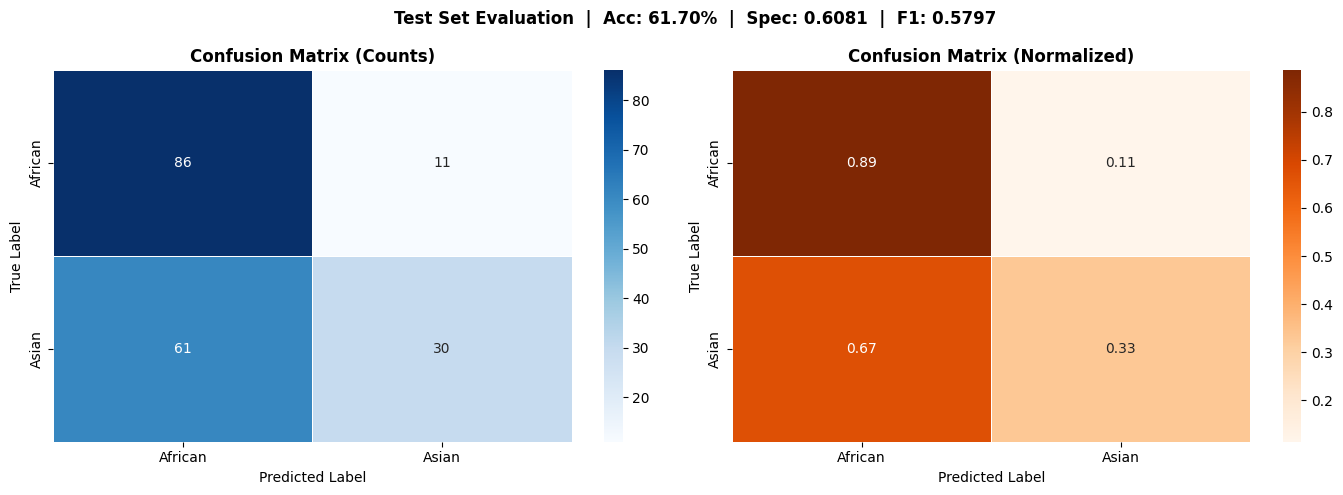


──────────────────────────────────────────────────────────
 Per-Class Classification Report
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     African     0.5850    0.8866    0.7049        97
       Asian     0.7317    0.3297    0.4545        91

    accuracy                         0.6170       188
   macro avg     0.6584    0.6081    0.5797       188
weighted avg     0.6560    0.6170    0.5837       188

──────────────────────────────────────────────────────────
 Macro-Averaged Test Metrics (Order: Acc → Prec → Rec → Spec → F1)
──────────────────────────────────────────────────────────
  1. Accuracy    : 61.70%
  2. Precision   : 0.6584
  3. Recall      : 0.6081
  4. Specificity : 0.6081
  5. F1 Score    : 0.5797
──────────────────────────────────────────────────────────

Experiment complete: RESNET50 | Sobel

  EXPERIMENT: DENSENET121 | Original

[Step 1] Loading data...
  Class names : ['African', 'Asian']
  Train

100%|██████████| 30.8M/30.8M [00:00<00:00, 102MB/s]


  Architecture   : densenet121
  Trainable params (Stage 1): 2,162,178 / 6,955,906

[Step 3] Training for 25 epochs...
  Columns → Loss tr/va | Acc | Prec | Rec | Spec | F1 | LR
  ---------------------------------------------------------------------------


Training:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01/25 | Loss: 0.7046/0.6356 | Acc: 62.9%/73.0% | Prec: 0.630/0.777 | Rec: 0.629/0.730 | Spec: 0.629/0.730 | F1: 0.628/0.718 | LR: 9.96e-04
Epoch 02/25 | Loss: 0.5378/0.6378 | Acc: 72.8%/72.2% | Prec: 0.729/0.744 | Rec: 0.728/0.722 | Spec: 0.728/0.722 | F1: 0.728/0.716 | LR: 9.84e-04
Epoch 03/25 | Loss: 0.4898/0.6445 | Acc: 77.2%/65.1% | Prec: 0.772/0.676 | Rec: 0.772/0.651 | Spec: 0.772/0.651 | F1: 0.772/0.638 | LR: 9.65e-04
Epoch 04/25 | Loss: 0.4632/0.6461 | Acc: 77.2%/72.2% | Prec: 0.772/0.736 | Rec: 0.772/0.722 | Spec: 0.772/0.722 | F1: 0.772/0.718 | LR: 9.38e-04
Epoch 05/25 | Loss: 0.4042/0.7425 | Acc: 82.2%/66.7% | Prec: 0.823/0.671 | Rec: 0.822/0.667 | Spec: 0.822/0.667 | F1: 0.822/0.665 | LR: 9.05e-04
Epoch 06/25 | Loss: 0.3540/0.7883 | Acc: 84.6%/64.3% | Prec: 0.847/0.643 | Rec: 0.846/0.643 | Spec: 0.846/0.643 | F1: 0.846/0.643 | LR: 8.65e-04
Epoch 07/25 | Loss: 0.3857/0.8963 | Acc: 83.5%/71.4% | Prec: 0.835/0.725 | Rec: 0.835/0.714 | Spec: 0.835/0.714 | F1: 0.835/0.711 

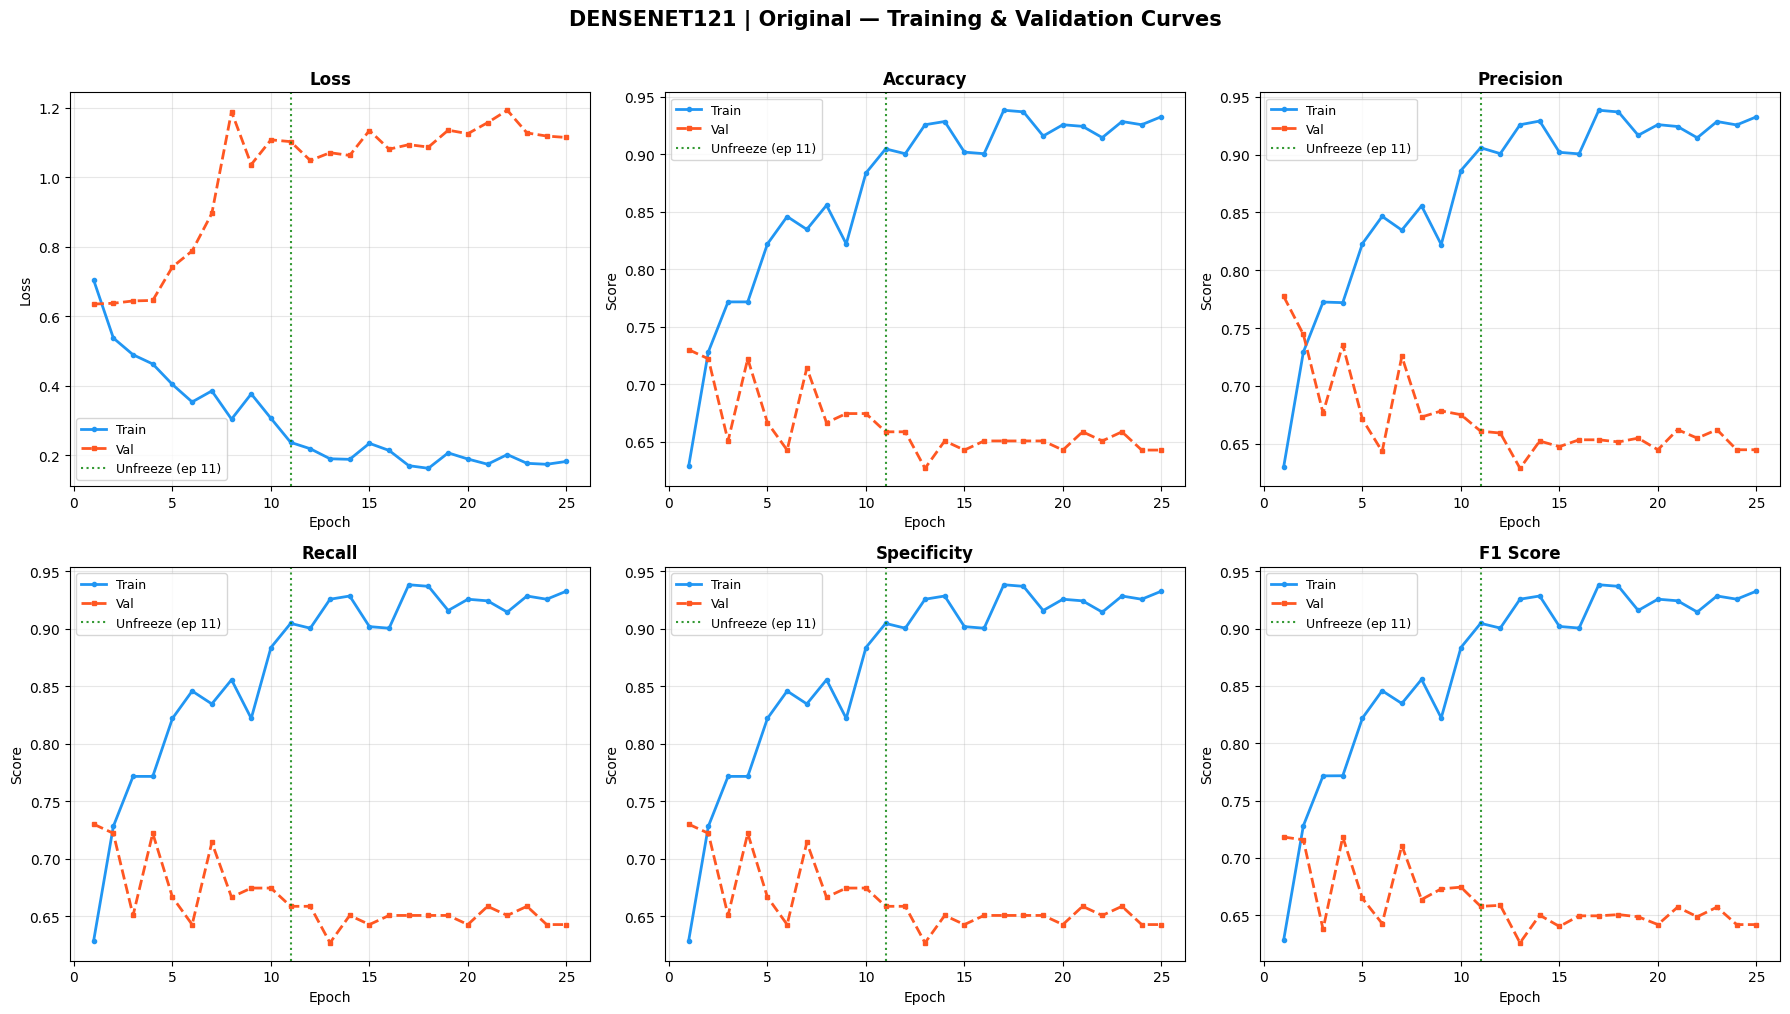


[Step 5] Evaluating on test set...


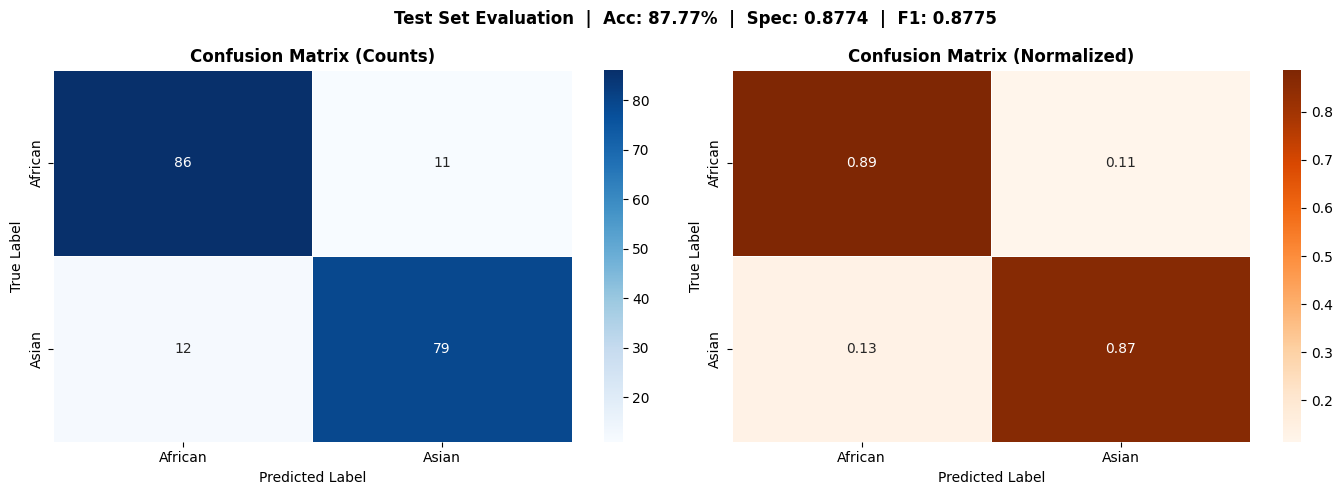


──────────────────────────────────────────────────────────
 Per-Class Classification Report
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     African     0.8776    0.8866    0.8821        97
       Asian     0.8778    0.8681    0.8729        91

    accuracy                         0.8777       188
   macro avg     0.8777    0.8774    0.8775       188
weighted avg     0.8777    0.8777    0.8776       188

──────────────────────────────────────────────────────────
 Macro-Averaged Test Metrics (Order: Acc → Prec → Rec → Spec → F1)
──────────────────────────────────────────────────────────
  1. Accuracy    : 87.77%
  2. Precision   : 0.8777
  3. Recall      : 0.8774
  4. Specificity : 0.8774
  5. F1 Score    : 0.8775
──────────────────────────────────────────────────────────

Experiment complete: DENSENET121 | Original

  EXPERIMENT: DENSENET121 | CLAHE

[Step 1] Loading data...
  Class names : ['African', 'Asian']
  Tr

Training:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01/25 | Loss: 0.6553/0.6726 | Acc: 64.1%/64.3% | Prec: 0.642/0.665 | Rec: 0.641/0.643 | Spec: 0.641/0.643 | F1: 0.641/0.631 | LR: 9.96e-04
Epoch 02/25 | Loss: 0.5505/0.5630 | Acc: 73.4%/74.6% | Prec: 0.734/0.747 | Rec: 0.734/0.746 | Spec: 0.734/0.746 | F1: 0.734/0.746 | LR: 9.84e-04
Epoch 03/25 | Loss: 0.4937/0.5844 | Acc: 74.8%/74.6% | Prec: 0.748/0.759 | Rec: 0.748/0.746 | Spec: 0.748/0.746 | F1: 0.748/0.743 | LR: 9.65e-04
Epoch 04/25 | Loss: 0.4385/0.7758 | Acc: 77.6%/69.8% | Prec: 0.776/0.716 | Rec: 0.776/0.698 | Spec: 0.776/0.698 | F1: 0.776/0.692 | LR: 9.38e-04
Epoch 05/25 | Loss: 0.3775/0.8583 | Acc: 81.8%/70.6% | Prec: 0.819/0.719 | Rec: 0.818/0.706 | Spec: 0.818/0.706 | F1: 0.818/0.702 | LR: 9.05e-04
Epoch 06/25 | Loss: 0.3525/0.9673 | Acc: 84.7%/66.7% | Prec: 0.849/0.678 | Rec: 0.847/0.667 | Spec: 0.847/0.667 | F1: 0.847/0.661 | LR: 8.65e-04
Epoch 07/25 | Loss: 0.3663/1.2238 | Acc: 82.2%/67.5% | Prec: 0.822/0.678 | Rec: 0.822/0.675 | Spec: 0.822/0.675 | F1: 0.822/0.673 

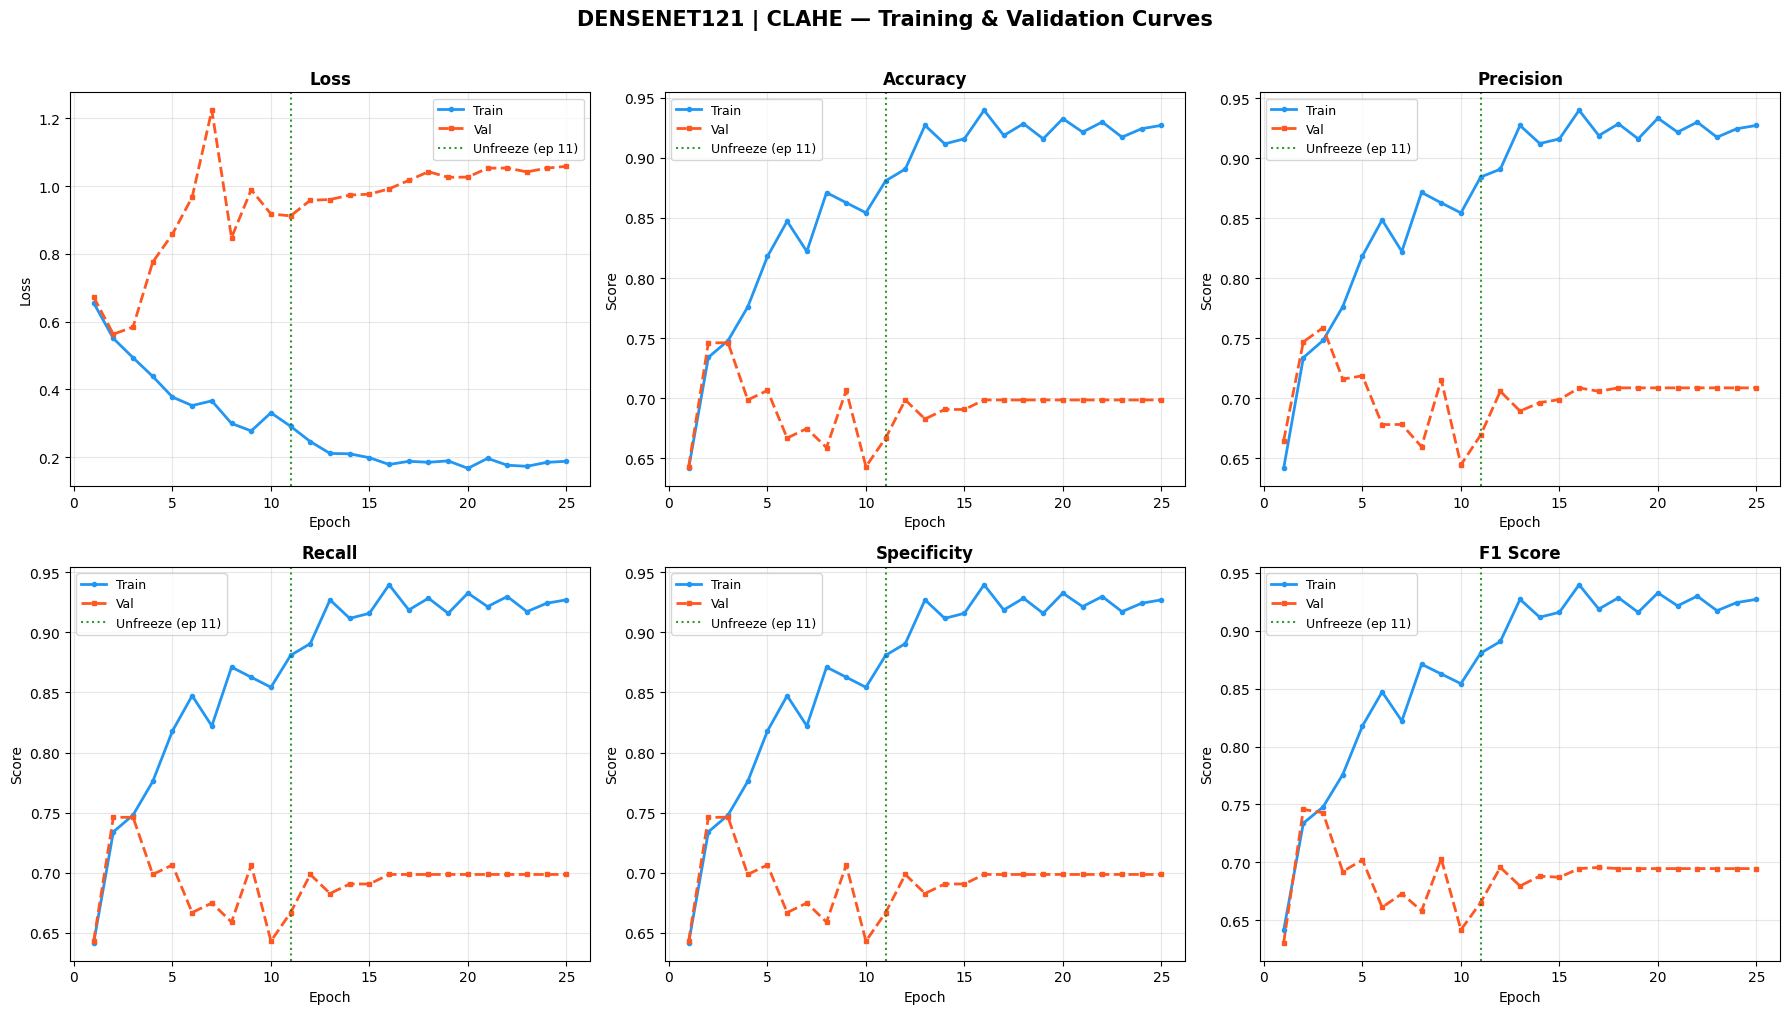


[Step 5] Evaluating on test set...


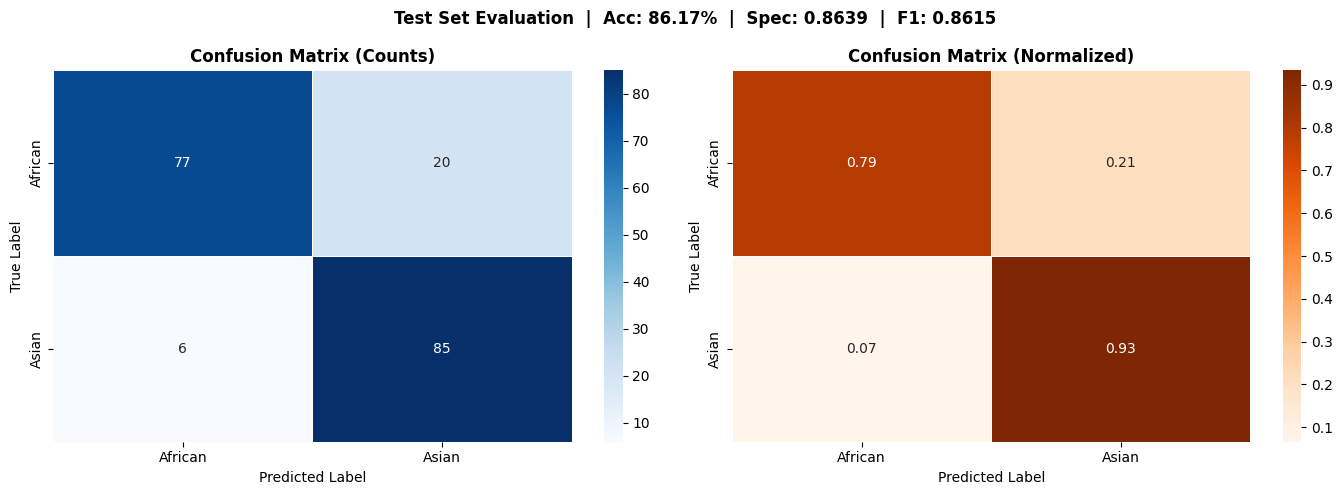


──────────────────────────────────────────────────────────
 Per-Class Classification Report
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     African     0.9277    0.7938    0.8556        97
       Asian     0.8095    0.9341    0.8673        91

    accuracy                         0.8617       188
   macro avg     0.8686    0.8639    0.8615       188
weighted avg     0.8705    0.8617    0.8613       188

──────────────────────────────────────────────────────────
 Macro-Averaged Test Metrics (Order: Acc → Prec → Rec → Spec → F1)
──────────────────────────────────────────────────────────
  1. Accuracy    : 86.17%
  2. Precision   : 0.8686
  3. Recall      : 0.8639
  4. Specificity : 0.8639
  5. F1 Score    : 0.8615
──────────────────────────────────────────────────────────

Experiment complete: DENSENET121 | CLAHE

  EXPERIMENT: DENSENET121 | Sobel

[Step 1] Loading data...
  Class names : ['African', 'Asian']
  Train

Training:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 01/25 | Loss: 0.7761/0.7483 | Acc: 54.9%/48.4% | Prec: 0.549/0.476 | Rec: 0.549/0.484 | Spec: 0.549/0.484 | F1: 0.549/0.435 | LR: 9.96e-04
Epoch 02/25 | Loss: 0.7048/0.7060 | Acc: 58.4%/52.4% | Prec: 0.587/0.527 | Rec: 0.584/0.524 | Spec: 0.584/0.524 | F1: 0.581/0.509 | LR: 9.84e-04
Epoch 03/25 | Loss: 0.6931/0.7088 | Acc: 59.0%/58.7% | Prec: 0.590/0.609 | Rec: 0.590/0.587 | Spec: 0.590/0.587 | F1: 0.590/0.566 | LR: 9.65e-04
Epoch 04/25 | Loss: 0.6678/0.6848 | Acc: 62.5%/54.8% | Prec: 0.625/0.563 | Rec: 0.625/0.548 | Spec: 0.625/0.548 | F1: 0.624/0.518 | LR: 9.38e-04
Epoch 05/25 | Loss: 0.6594/0.7199 | Acc: 60.1%/56.3% | Prec: 0.601/0.584 | Rec: 0.601/0.563 | Spec: 0.601/0.563 | F1: 0.600/0.535 | LR: 9.05e-04
Epoch 06/25 | Loss: 0.6454/0.8793 | Acc: 64.1%/53.2% | Prec: 0.641/0.633 | Rec: 0.641/0.532 | Spec: 0.641/0.532 | F1: 0.641/0.422 | LR: 8.65e-04
Epoch 07/25 | Loss: 0.6365/0.7716 | Acc: 66.1%/57.9% | Prec: 0.662/0.597 | Rec: 0.661/0.579 | Spec: 0.661/0.579 | F1: 0.661/0.559 

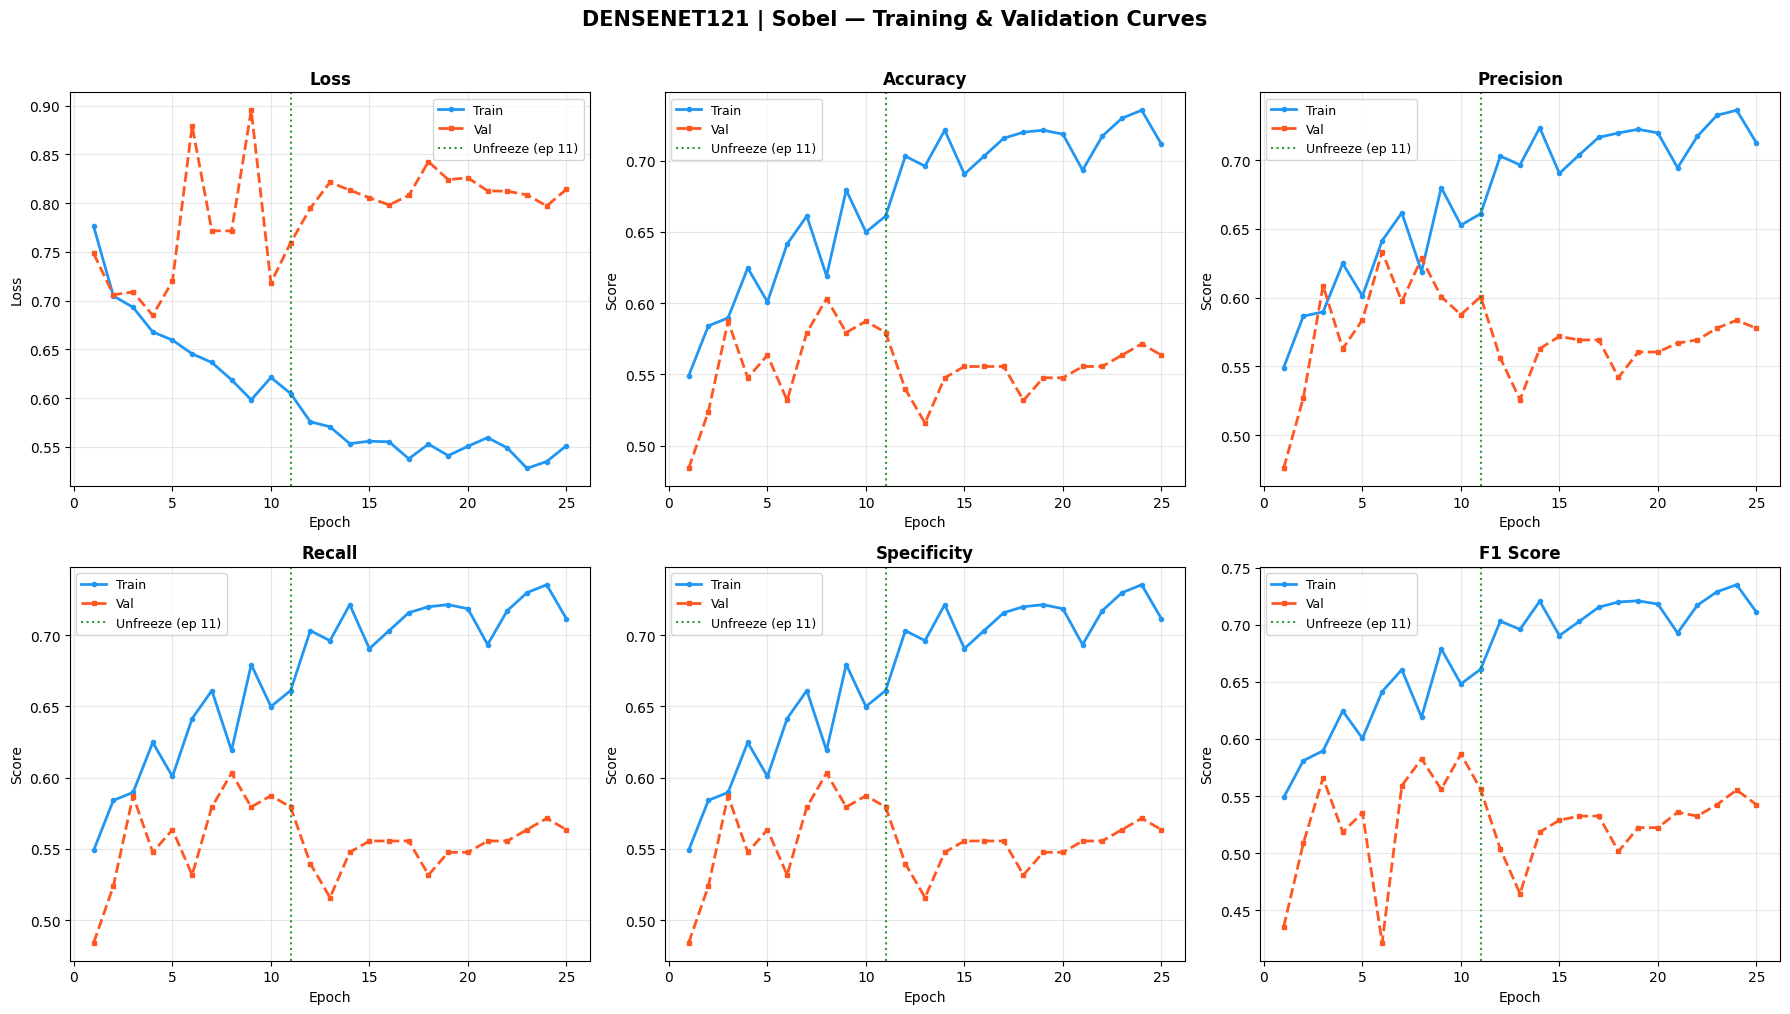


[Step 5] Evaluating on test set...


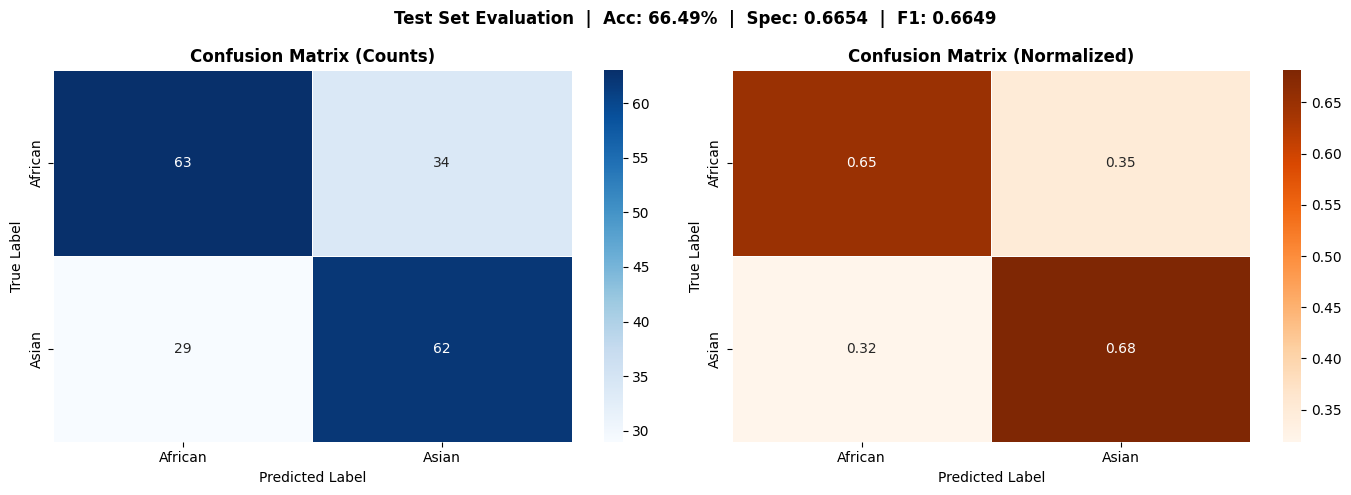


──────────────────────────────────────────────────────────
 Per-Class Classification Report
──────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     African     0.6848    0.6495    0.6667        97
       Asian     0.6458    0.6813    0.6631        91

    accuracy                         0.6649       188
   macro avg     0.6653    0.6654    0.6649       188
weighted avg     0.6659    0.6649    0.6649       188

──────────────────────────────────────────────────────────
 Macro-Averaged Test Metrics (Order: Acc → Prec → Rec → Spec → F1)
──────────────────────────────────────────────────────────
  1. Accuracy    : 66.49%
  2. Precision   : 0.6653
  3. Recall      : 0.6654
  4. Specificity : 0.6654
  5. F1 Score    : 0.6649
──────────────────────────────────────────────────────────

Experiment complete: DENSENET121 | Sobel

  ALL 6 EXPERIMENTS COMPLETE
  Total runtime: 39.9 minutes


In [17]:
# Storage for test metrics from all experiments
# Keys: (model_name, dataset_tag) → Values: {accuracy, precision, recall, specificity, f1}
all_metrics = {}

# Dataset variants to evaluate
datasets_config = {
    "Original" : (train_dir,   val_dir,   test_dir),
    "CLAHE"    : (train_clahe, val_clahe, test_clahe),
    "Sobel"    : (train_sobel, val_sobel, test_sobel),
}

# Models to evaluate
model_names = ["resnet50", "densenet121"]

# Run all 6 experiments
experiment_start = timer()

for model_name in model_names:
    for dataset_tag, (tr, va, te) in datasets_config.items():
        metrics = run_experiment(
            model_name=model_name,
            train_dir=tr,
            val_dir=va,
            test_dir=te,
            dataset_tag=dataset_tag,
            epochs=NUM_EPOCHS
        )
        all_metrics[(model_name, dataset_tag)] = metrics

experiment_end = timer()
total_time = (experiment_end - experiment_start) / 60

print(f"\n{'='*50}")
print(f"  ALL 6 EXPERIMENTS COMPLETE")
print(f"  Total runtime: {total_time:.1f} minutes")
print(f"{'='*50}")

---
## Cell 17 — Final Comparison Charts  (Updated — All 5 Metrics)

Now that all experiments are complete, we call `plot_metrics_comparison()` to generate
a 2×3 grid of bar charts — one for each of the five metrics — showing every model–dataset
combination side by side.

The sixth panel shows the best overall result (by F1 score) as a summary box.

/tmp/ipykernel_9309/1636197496.py:90: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


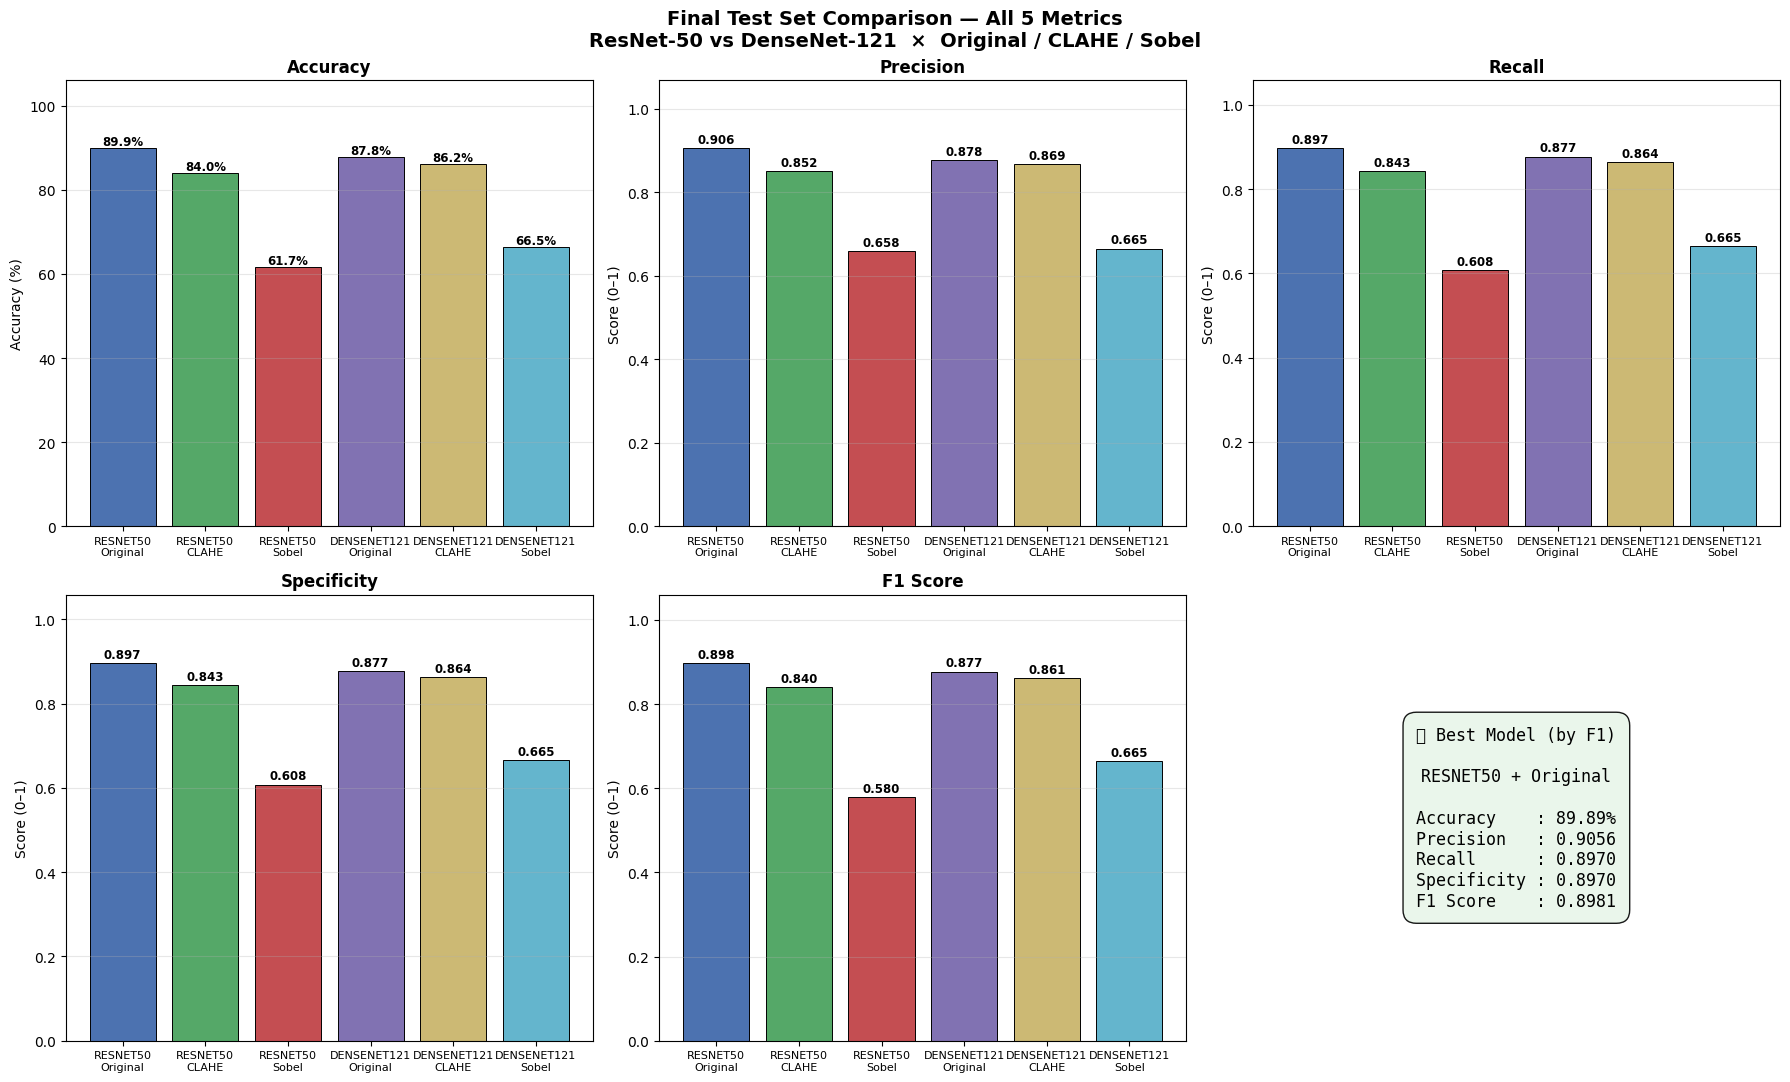

In [23]:
plot_metrics_comparison(all_metrics)

---
## Cell 18 — Full Summary Table

We build a structured pandas DataFrame containing all five metrics for every experiment.

**Columns are in the fixed order: Accuracy → Precision → Recall → Specificity → F1 Score**

**Color coding:**
- 🟢 Green cell = best value in that column across all experiments
- 🔴 Red cell = worst value in that column across all experiments

This table is ready to be included directly in a research paper or project report.

In [24]:
# Build Results DataFrame
rows = []
for (model_name, dataset_tag), m in all_metrics.items():
    rows.append({
        "Model"       : model_name.upper(),
        "Dataset"     : dataset_tag,
        "Accuracy"    : round(m["accuracy"]    * 100, 2),   # shown as percentage
        "Precision"   : round(m["precision"],    4),
        "Recall"      : round(m["recall"],       4),
        "Specificity" : round(m["specificity"],  4),
        "F1 Score"    : round(m["f1"],           4),
    })

df = pd.DataFrame(rows)

# Style: highlight best (green) and worst (red) per column
metric_cols = ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score"]

styled = (
    df.style
    .highlight_max(subset=metric_cols, color="#A5D6A7")   # Green = best
    .highlight_min(subset=metric_cols, color="#FFCDD2")   # Red = worst
    .set_caption(
        "Test Set Results — 5 Metrics (macro-averaged) | "
        "Order: Accuracy → Precision → Recall → Specificity → F1 | "
        "🟢 Best  🔴 Worst"
    )
    .format({
        "Accuracy"    : "{:.2f}%",
        "Precision"   : "{:.4f}",
        "Recall"      : "{:.4f}",
        "Specificity" : "{:.4f}",
        "F1 Score"    : "{:.4f}"
    })
)
display(styled)

# Plain text version
print("\nPlain text summary (column order: Acc → Prec → Rec → Spec → F1):")
print(df.to_string(index=False))

# Best and worst results
best_idx  = df["F1 Score"].idxmax()
worst_idx = df["F1 Score"].idxmin()
best_row  = df.loc[best_idx]
worst_row = df.loc[worst_idx]

print(f"\n{'─'*60}")
print(f"  🏆 BEST  → {best_row['Model']} + {best_row['Dataset']}")
print(f"     Accuracy    : {best_row['Accuracy']}%")
print(f"     Precision   : {best_row['Precision']}")
print(f"     Recall      : {best_row['Recall']}")
print(f"     Specificity : {best_row['Specificity']}")
print(f"     F1 Score    : {best_row['F1 Score']}")
print(f"\n  ⚠️  WORST → {worst_row['Model']} + {worst_row['Dataset']}")
print(f"     Accuracy    : {worst_row['Accuracy']}%")
print(f"     Precision   : {worst_row['Precision']}")
print(f"     Recall      : {worst_row['Recall']}")
print(f"     Specificity : {worst_row['Specificity']}")
print(f"     F1 Score    : {worst_row['F1 Score']}")
print(f"{'─'*60}")

,Model,Dataset,Accuracy,Precision,Recall,Specificity,F1 Score
0,RESNET50,Original,89.89%,0.9056,0.8970,0.8970,0.8981
1,RESNET50,CLAHE,84.04%,0.8519,0.8433,0.8433,0.8398
2,RESNET50,Sobel,61.70%,0.6584,0.6081,0.6081,0.5797
3,DENSENET121,Original,87.77%,0.8777,0.8774,0.8774,0.8775
4,DENSENET121,CLAHE,86.17%,0.8686,0.8639,0.8639,0.8615
5,DENSENET121,Sobel,66.49%,0.6653,0.6654,0.6654,0.6649



Plain text summary (column order: Acc → Prec → Rec → Spec → F1):
      Model  Dataset  Accuracy  Precision  Recall  Specificity  F1 Score
   RESNET50 Original     89.89     0.9056  0.8970       0.8970    0.8981
   RESNET50    CLAHE     84.04     0.8519  0.8433       0.8433    0.8398
   RESNET50    Sobel     61.70     0.6584  0.6081       0.6081    0.5797
DENSENET121 Original     87.77     0.8777  0.8774       0.8774    0.8775
DENSENET121    CLAHE     86.17     0.8686  0.8639       0.8639    0.8615
DENSENET121    Sobel     66.49     0.6653  0.6654       0.6654    0.6649

────────────────────────────────────────────────────────────
  🏆 BEST  → RESNET50 + Original
     Accuracy    : 89.89%
     Precision   : 0.9056
     Recall      : 0.897
     Specificity : 0.897
     F1 Score    : 0.8981

  ⚠️  WORST → RESNET50 + Sobel
     Accuracy    : 61.7%
     Precision   : 0.6584
     Recall      : 0.6081
     Specificity : 0.6081
     F1 Score    : 0.5797
────────────────────────────────────────